# PDDL Attack Path Evaluation
Evaluate generated PDDL attack paths: solvability, syntax, and semantic quality.

## 1. Environment Setup (imports, constnats, global variables)

In [104]:
import sys
import os
import re
import json
from dataclasses import dataclass
from pathlib import Path
import numpy as np

from cve2pddlap.core.data_loader import load_few_shot_pool
from cve2pddlap.evaluation import create_ff_checker, create_enhsp_checker
from cve2pddlap.evaluation.problem_pddl_generator import generate_problem
from cve2pddlap.llm_providers.remote.openai_compat import QwenProvider


import torch
from sentence_transformers import SentenceTransformer, util as st_util
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline as hf_pipeline

from openai import OpenAI

from jinja2 import Environment, FileSystemLoader


# Project root (relative — works from notebooks/attack_paths/)
PROJECT_ROOT = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..', '..'))
sys.path.insert(0, os.path.join(PROJECT_ROOT, 'src'))

# Data paths and file names
DATASET_PATH = os.path.join(PROJECT_ROOT, 'resources', 'data', 'CVE-PDDL-NNL-ReAP')
TARGET_POOL_FILE = os.path.join(PROJECT_ROOT, 'resources', 'data', 'target_pool.json')
GENERATED_DOMAIN_DIR = os.path.join(PROJECT_ROOT, 'generated_domain')
FIG_DIR = os.path.join(PROJECT_ROOT, 'Fig', 'embedding_intrinsic')
os.makedirs(FIG_DIR, exist_ok=True)
FIG_DIR_EXT = os.path.join(PROJECT_ROOT, 'Fig', 'embedding_extrinsic')
os.makedirs(FIG_DIR_EXT, exist_ok=True)
EVAL_SET_DIR = os.path.join(GENERATED_DOMAIN_DIR, 'eval_set')
PROMPTS_PATH = os.path.join(PROJECT_ROOT, 'resources', 'prompt', 'evaluation')
AP_PATTERN = re.compile(r'^AP\d+$')
DOMAIN_FILE = 'domain.pddl'
PROBLEM_FILE = 'problem.pddl'

# Models (small defaults — replace with preferred models)
EMBEDDING_MODEL_NAME_B = "BAAI/bge-base-en-v1.5"  # stronger general model with safetensors support
LLM_MODEL_NAME = "HuggingFaceTB/SmolLM2-1.7B-Instruct"

# Generation parameters
SEED = 42
TEMPERATURE = 0.0
TOP_K = 1


@dataclass(frozen=True)
class EvaluationFlags:
    syntax_check: bool = True
    embedding_intrinsic: bool = True
    embedding_extrinsic: bool = True
    llm_intrinsic: bool = True
    llm_extrinsic: bool = True


eval_flags = EvaluationFlags()

## 2. Load data, Prompts, LLM (tokenizer and embedding model)

In [105]:
few_shot_pool = load_few_shot_pool(DATASET_PATH)
print(f'Reference examples: {len(few_shot_pool)}')
for ex in few_shot_pool[:5]:
    print(f'  {ex.key}')
print('  ...')
print(f'Generated domain dir to be evaluated: {os.path.relpath(EVAL_SET_DIR)}')

Reference examples: 55
  CVE-2022-1471 / AP1
  CVE-2022-40149 / AP1
  CVE-2022-40149 / AP2
  CVE-2022-40150 / AP1
  CVE-2022-40150 / AP2
  ...
Generated domain dir to be evaluated: ../../generated_domain/eval_set


In [106]:
few_shot_pool = load_few_shot_pool(DATASET_PATH)
print(f'Reference examples: {len(few_shot_pool)}')
for ex in few_shot_pool[:5]:
    print(f'  {ex.key}')
print('  ...')
print(f'Generated domain dir to be evaluated: {os.path.relpath(EVAL_SET_DIR)}')


def load_target_pool(target_pool_file):
    """Load CVE descriptions from target_pool.json. Returns {cve_id: description}."""
    with open(target_pool_file, encoding='utf-8') as f:
        pool = json.load(f)
    return {entry['cve_id']: entry['description'] for entry in pool}


def load_dataset(data_path, cve_descriptions):
    """Load all CVEs with their descriptions (from target_pool) and attack path PDDL files."""
    dataset = []
    for cve_dir in sorted(Path(data_path).iterdir()):
        if not cve_dir.is_dir():
            continue
        cve_id = cve_dir.name
        description = cve_descriptions.get(cve_id)
        if description is None:
            continue
        attack_paths = []
        for ap_dir in sorted(cve_dir.iterdir()):
            if not ap_dir.is_dir() or not AP_PATTERN.match(ap_dir.name):
                continue
            domain_file = ap_dir / DOMAIN_FILE
            problem_file = ap_dir / PROBLEM_FILE
            if domain_file.exists() and problem_file.exists():
                attack_paths.append({
                    'ap_id': ap_dir.name,
                    'domain': domain_file.read_text(encoding='utf-8').strip(),
                    'problem': problem_file.read_text(encoding='utf-8').strip(),
                })
        dataset.append({
            'cve_id': cve_id,
            'description': description,
            'attack_paths': attack_paths,
        })
    return dataset


def load_prompts(prompts_path):
    """Load Jinja2 evaluation prompt templates."""
    return Environment(loader=FileSystemLoader(prompts_path))


def load_embedding_model(model_name):
    """Load a SentenceTransformer bi-encoder model."""
    return SentenceTransformer(model_name)


def load_llm(model_name):
    """Load a HuggingFace causal LLM with its tokenizer."""
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        dtype=torch.float16,
        device_map='auto',
    )
    gen = hf_pipeline(
        'text-generation',
        model=model,
        tokenizer=tokenizer,
        max_new_tokens=512,
        do_sample=False,
    )
    return gen, tokenizer


cve_descriptions = load_target_pool(TARGET_POOL_FILE)
dataset = load_dataset(DATASET_PATH, cve_descriptions)
prompt_env = load_prompts(PROMPTS_PATH)

embedding_model = None
if eval_flags.embedding_intrinsic or eval_flags.embedding_extrinsic:
    embedding_model = load_embedding_model(EMBEDDING_MODEL_NAME)

# Load embedding model B (bge-base)
embedding_model_b = None
if eval_flags.embedding_intrinsic or eval_flags.embedding_extrinsic:
    embedding_model_b = SentenceTransformer(EMBEDDING_MODEL_NAME_B)

llm, tokenizer = None, None
if eval_flags.llm_intrinsic or eval_flags.llm_extrinsic:
    llm, tokenizer = load_llm(LLM_MODEL_NAME)

Reference examples: 55
  CVE-2022-1471 / AP1
  CVE-2022-40149 / AP1
  CVE-2022-40149 / AP2
  CVE-2022-40150 / AP1
  CVE-2022-40150 / AP2
  ...
Generated domain dir to be evaluated: ../../generated_domain/eval_set


Device set to use cpu


## 3. Evaluation

### 3.1 Syntactic

#### 3.1.1 Intrinsic: PDDL AP Syntax and Solvability Check

Block 1: The function that tests if the code is syntactically correct

In [107]:
ff = create_ff_checker()
enhsp = create_enhsp_checker()

def check_pddl_ap_syntax(domain_str, problem_save_path=None):
    """Generate problem from domain, then check syntax (ENHSP) and solvability (FF).
    If problem_save_path is provided, saves problem.pddl to that path."""
    problem_str = generate_problem(domain_str, save_path=problem_save_path)
    r_ff = ff.check_from_string(domain_str, problem_str)
    r_enhsp = enhsp.check_from_string(domain_str, problem_str)
    return r_enhsp.success, r_ff.solvable, r_ff.plan, r_enhsp.error or r_ff.error

Block 2: Call the function with the code from the data set

In [108]:
#Reference domains (from dataset, problem already exists but we regenerate for consistency)
# reference_ap_syntax_results = []
# for entry in dataset:
#      for ap in entry['attack_paths']:
#          enhsp_ok, ff_solvable, plan, err = check_pddl_ap_syntax(ap['domain'])
#          result = {
#              'source': 'reference',
#              'cve_id': entry['cve_id'],
#              'ap_id': ap['ap_id'],
#              'syntax_ok': enhsp_ok,
#              'solvable': ff_solvable,
#              'ap': plan,
#              'error': err,
#          }
#          reference_ap_syntax_results.append(result)
#          print(f"Reference: {entry['cve_id']}/{ap['ap_id']}  syntax:{enhsp_ok}  solvable:{ff_solvable}")
#          if plan:
#              for i, action in enumerate(plan):
#                  print(f"  {i}: {action}")

# Generated domains (from eval_set/<CVE-ID>/llm_config/domain.pddl)
# Problem saved to eval_set/C<CVE-ID>/llm_config/problem.pddl
generated_ap_syntax_results = []
eval_set_path = Path(EVAL_SET_DIR)
for cve_dir in sorted(eval_set_path.iterdir()):
    if not cve_dir.is_dir():
        continue
    for config_dir in sorted(cve_dir.iterdir()):
        if not config_dir.is_dir():
            continue
        domain_file = config_dir / 'domain.pddl'
        if not domain_file.exists():
            continue
        domain_str = domain_file.read_text(encoding='utf-8')
        problem_save = str(config_dir / 'problem.pddl')
        enhsp_ok, ff_solvable, plan, err = check_pddl_ap_syntax(domain_str, problem_save_path=problem_save)
        result = {
            'source': 'generated',
            'cve_id': cve_dir.name,
            'config': config_dir.name,
            'syntax_ok': enhsp_ok,
            'solvable': ff_solvable,
            'ap': plan,
            'error': err,
        }
        generated_ap_syntax_results.append(result)
        print(f"Generated: {cve_dir.name}/{config_dir.name}  syntax:{enhsp_ok}  solvable:{ff_solvable}")
        if plan:
            for i, action in enumerate(plan):
                print(f"  {i}: {action}")

Generated: CVE-2022-1471/gpt41_baseline_cveonly  syntax:True  solvable:True
  0: ATTACKER-CRAFTS-MALICIOUS-YAML-PAYLOAD SEFA MALICIOUS-YAML-PAYLOAD_SEFA SNAKEYAML-LIBRARY CVE_2022_1471
  1: ATTACKER-SENDS-HTTP-POST-REQUEST-WITH-MALICIOUS-YAML SEFA HTTP-POST-REQUEST_SEFA MALICIOUS-YAML-PAYLOAD_SEFA API-ENDPOINT_SEFA CVE_2022_1471
  2: TARGET-SYSTEM-RECEIVES-HTTP-POST-REQUEST-WITH-MALICIOUS-YAML SEFA HTTP-POST-REQUEST_SEFA MALICIOUS-YAML-PAYLOAD_SEFA API-ENDPOINT_SEFA
  3: TARGET-SYSTEM-EXTRACTS-YAML-PAYLOAD-FROM-HTTP-REQUEST SEFA HTTP-POST-REQUEST_SEFA MALICIOUS-YAML-PAYLOAD_SEFA API-ENDPOINT_SEFA
  4: TARGET-SYSTEM-INVOKES-SNAKEYAML-CONSTRUCTOR-ON-MALICIOUS-PAYLOAD SEFA SNAKEYAML-LIBRARY MALICIOUS-YAML-PAYLOAD_SEFA
  5: ATTACKER-GAINS-REMOTE-CODE-EXECUTION-VIA-ARBITRARY-OBJECT-INSTANTIATION SEFA MALICIOUS-YAML-PAYLOAD_SEFA
  6: ATTACKER-ACHIEVES-ELEVATION-OF-PRIVILEGE-ON-TARGET-SYSTEM SEFA
Generated: CVE-2022-1471/gpt41mini_ctx_feedback  syntax:True  solvable:True
  0: ATTACKER-CRAFTS-

#### 3.1.2 Extrinsic (future)

In [109]:
# TODO: extrinsic syntactic evaluation

### 3.2 Semantic Evaluation

#### 3.2.1 Intrinsic

##### 3.2.1.1 Embedding: NL CVE Description vs PDDL Similarity

Block 1:  the function to compute the embedding similarity between the informal (natural language) specification and the PDDL code (domain + problem)

In [110]:
def embedding_similarity_intrinsic(descriptions, pddl_texts, model):
    """Cosine similarity matrix between NL descriptions and PDDL codes.
    Args:
        descriptions: list of NL description strings
        pddl_texts: list of PDDL (domain+problem) strings
        model: SentenceTransformer model
    Returns:
        numpy array of shape (len(descriptions), len(pddl_texts))
    """
    E_desc = model.encode(
        descriptions,
        convert_to_tensor=True,
        normalize_embeddings=True,
        show_progress_bar=False,
    )
    E_pddl = model.encode(
        pddl_texts,
        convert_to_tensor=True,
        normalize_embeddings=True,
        show_progress_bar=False,
    )
    S = E_desc @ E_pddl.T
    return S.float().cpu().numpy()

Block 2: call the function with the code and the specifications from the data set

In [111]:
descriptions = []
pddl_texts = []
labels = []

eval_set_path = Path(EVAL_SET_DIR)
for cve_dir in sorted(eval_set_path.iterdir()):
    if not cve_dir.is_dir():
        continue
    cve_id = cve_dir.name
    description = cve_descriptions.get(cve_id)
    if description is None:
        print(f"SKIP {cve_id}: no description in target_pool.json")
        continue
    for config_dir in sorted(cve_dir.iterdir()):
        if not config_dir.is_dir():
            continue
        domain_file = config_dir / DOMAIN_FILE
        problem_file = config_dir / PROBLEM_FILE
        if not domain_file.exists():
            continue
        domain = domain_file.read_text(encoding='utf-8').strip()
        problem = problem_file.read_text(encoding='utf-8').strip() if problem_file.exists() else ''
        descriptions.append(description)
        pddl_texts.append(domain + '\n' + problem)
        labels.append(f"{cve_id}/{config_dir.name}")

sim_matrix = embedding_similarity_intrinsic(descriptions, pddl_texts, embedding_model)
emb_intrinsic_results = []
for i, label in enumerate(labels):
    sim = float(sim_matrix[i, i])
    emb_intrinsic_results.append({'label': label, 'similarity': sim})
    print(f"{label}  similarity: {sim:.4f}")

CVE-2022-1471/gpt41_baseline_cveonly  similarity: 0.3316
CVE-2022-1471/gpt41mini_ctx_feedback  similarity: 0.3025
CVE-2022-1471/gpt4mini_1shot_augmented  similarity: 0.2657
CVE-2022-1471/reference  similarity: 0.3815
CVE-2023-44487/gpt41mini_ctx_feedback  similarity: 0.4157
CVE-2023-44487/gpt41mini_feedback  similarity: 0.3638
CVE-2023-6378/reference  similarity: 0.4221
CVE-2025-24813/gpt41_ctx_feedback_v2  similarity: 0.5906
CVE-2025-24813/reference  similarity: 0.6422
CVE-2025-66032/gpt4_1shot  similarity: 0.3689
CVE-2025-66032/qwen-max_1shot  similarity: 0.3575


Block 3: Use bootstrapping to find the best threshold for the intrinsic semantic similarity.

In [112]:
def bootstrap_threshold(scores, n_bootstrap=10000, ci_alpha=0.05, seed=42):
    """Bootstrap the mean similarity to derive a threshold.
    Returns:
        ci_low: lower bound of (1 - ci_alpha) CI of bootstrapped means
        ci_high: upper bound
        boot_means: array of bootstrapped means
    """
    rng = np.random.default_rng(seed)
    n = len(scores)
    boot_means = np.array([
        rng.choice(scores, size=n, replace=True).mean()
        for _ in range(n_bootstrap)
    ])
    ci_low = np.percentile(boot_means, 100 * ci_alpha / 2)
    ci_high = np.percentile(boot_means, 100 * (1 - ci_alpha / 2))
    return ci_low, ci_high, boot_means


def collect_reference_scores_intrinsic(dataset, model):
    """Compute cosine similarities for all reference (description, domain+problem) pairs."""
    descriptions = []
    pddl_texts = []
    for entry in dataset:
        for ap in entry['attack_paths']:
            descriptions.append(entry['description'])
            pddl_texts.append(ap['domain'] + '\n' + ap['problem'])
    E_desc = model.encode(descriptions, convert_to_tensor=True, normalize_embeddings=True, show_progress_bar=False)
    E_pddl = model.encode(pddl_texts, convert_to_tensor=True, normalize_embeddings=True, show_progress_bar=False)
    scores = (E_desc * E_pddl).sum(dim=1).float().cpu().numpy()
    return scores


scores_intrinsic = collect_reference_scores_intrinsic(dataset, embedding_model)
ci_low_i, ci_high_i, boot_means_i = bootstrap_threshold(scores_intrinsic, seed=SEED)

print(f"Intrinsic threshold (model={EMBEDDING_MODEL_NAME}, n={len(scores_intrinsic)})")
print(f"  mean={scores_intrinsic.mean():.4f}  std={scores_intrinsic.std():.4f}  "
      f"min={scores_intrinsic.min():.4f}  max={scores_intrinsic.max():.4f}")
print(f"  95% CI of mean: [{ci_low_i:.4f}, {ci_high_i:.4f}]")
print(f"  Suggested threshold (CI lower bound): {ci_low_i:.4f}")

Intrinsic threshold (model=all-MiniLM-L6-v2, n=55)
  mean=0.4252  std=0.0950  min=0.1983  max=0.6557
  95% CI of mean: [0.4000, 0.4501]
  Suggested threshold (CI lower bound): 0.4000


Explaination:                                                                      
  - mean=0.4252: The average similarity across all correct matches. The relatively low value is expected: NL vulnerability descriptions and PDDL code are fundamentally different representations, so even correct pairs don't score near 1.0.
  - std=0.0950: Moderate variance across pairs, reflecting that some CVEs are easier to align than others. 
  - min=0.1983, max=0.6557: The weakest correct match scores only about 0.20; the strongest reaches 0.66.
  - 95% CI of mean: [0.4000, 0.4501]: The true population mean lies within [0.40, 0.45] with 95% confidence.
  - Suggested threshold = 0.4000: The CI lower bound. A generated PDDL scoring below 0.40 against its CVE description is performing worse than the average correct match, it should be flagged for human review.

Block 4: Visualize the intrinsic similarity distribution of the 55 references.

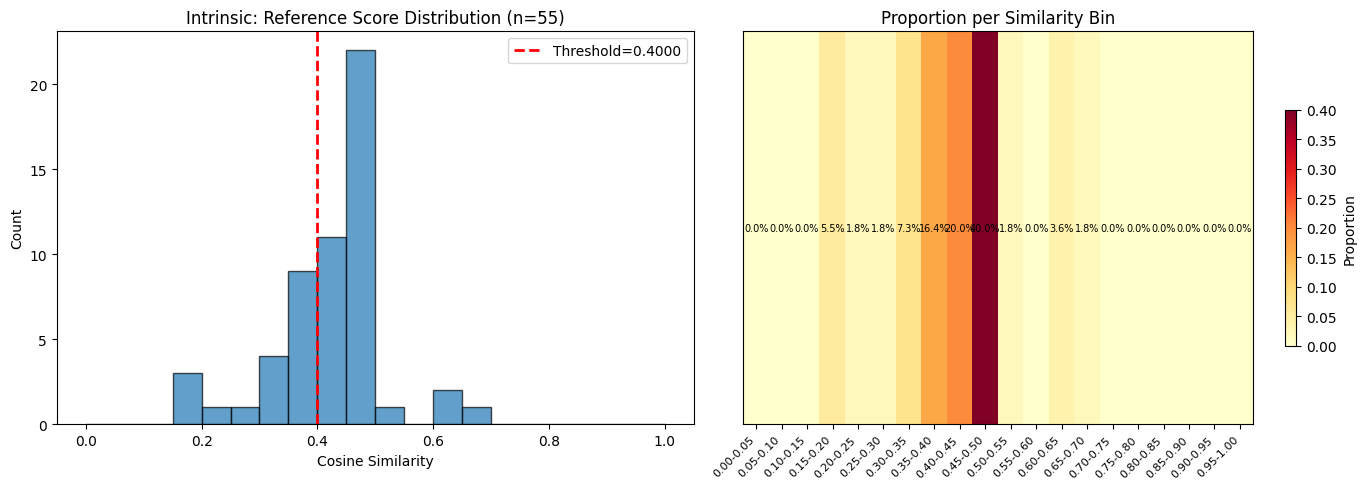

In [113]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram of reference scores
bins = np.arange(0.0, 1.05, 0.05)
counts, _, patches = axes[0].hist(scores_intrinsic, bins=bins, edgecolor='black', alpha=0.7)
axes[0].axvline(ci_low_i, color='red', linestyle='--', linewidth=2, label=f'Threshold={ci_low_i:.4f}')
axes[0].set_xlabel('Cosine Similarity')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Intrinsic: Reference Score Distribution (n={len(scores_intrinsic)})')
axes[0].legend()

# Right: heatmap of proportion per bin
bin_labels = [f'{b:.2f}-{b+0.05:.2f}' for b in bins[:-1]]
proportions = counts / counts.sum()
heatmap_data = proportions.reshape(1, -1)
im = axes[1].imshow(heatmap_data, aspect='auto', cmap='YlOrRd', vmin=0)
axes[1].set_xticks(range(len(bin_labels)))
axes[1].set_xticklabels(bin_labels, rotation=45, ha='right', fontsize=8)
axes[1].set_yticks([])
axes[1].set_title('Proportion per Similarity Bin')
for j in range(len(bin_labels)):
    axes[1].text(j, 0, f'{proportions[j]:.1%}', ha='center', va='center', fontsize=7)
fig.colorbar(im, ax=axes[1], shrink=0.6, label='Proportion')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'intrinsic_threshold_distribution.png'), dpi=150)
plt.show()

##### 3.2.1.1b Embedding Model B (bge-base): NL CVE Description vs PDDL Similarity

Repeat the intrinsic embedding evaluation using `BAAI/bge-base-en-v1.5` to compare with the general-purpose model (`all-MiniLM-L6-v2`) above.
- Why `BAAI/bge-base-en-v1.5`?
  - Strong MTEB performance. On the [Massive Text Embedding Benchmark](https://huggingface.co/spaces/mteb/leaderboard), bge-base is among the top-performing models in its size class (approximately 110M parameters).
  - Cross-modal capability for code and natural language. The bge series performs well on tasks such as code search and code–natural language matching, making it suitable for measuring cross-modal similarity between natural-language CVE descriptions and PDDL code.

In [114]:
# --- Intrinsic embedding with model B (bge-base) ---
# Reuse the same descriptions/pddl_texts/labels collected earlier

sim_matrix_b = embedding_similarity_intrinsic(descriptions, pddl_texts, embedding_model_b)
emb_intrinsic_results_b = []
for i, label in enumerate(labels):
    sim = float(sim_matrix_b[i, i])
    emb_intrinsic_results_b.append({'label': label, 'similarity': sim})
    print(f"[Model B] {label}  similarity: {sim:.4f}")

[Model B] CVE-2022-1471/gpt41_baseline_cveonly  similarity: 0.6716
[Model B] CVE-2022-1471/gpt41mini_ctx_feedback  similarity: 0.6985
[Model B] CVE-2022-1471/gpt4mini_1shot_augmented  similarity: 0.6241
[Model B] CVE-2022-1471/reference  similarity: 0.7166
[Model B] CVE-2023-44487/gpt41mini_ctx_feedback  similarity: 0.5747
[Model B] CVE-2023-44487/gpt41mini_feedback  similarity: 0.5791
[Model B] CVE-2023-6378/reference  similarity: 0.6589
[Model B] CVE-2025-24813/gpt41_ctx_feedback_v2  similarity: 0.7411
[Model B] CVE-2025-24813/reference  similarity: 0.7591
[Model B] CVE-2025-66032/gpt4_1shot  similarity: 0.7720
[Model B] CVE-2025-66032/qwen-max_1shot  similarity: 0.7083


In [115]:
# --- Intrinsic threshold for model B ---
scores_intrinsic_b = collect_reference_scores_intrinsic(dataset, embedding_model_b)
ci_low_ib, ci_high_ib, boot_means_ib = bootstrap_threshold(scores_intrinsic_b, seed=SEED)

print(f"Intrinsic threshold (model={EMBEDDING_MODEL_NAME_B}, n={len(scores_intrinsic_b)})")
print(f"  mean={scores_intrinsic_b.mean():.4f}  std={scores_intrinsic_b.std():.4f}  "
      f"min={scores_intrinsic_b.min():.4f}  max={scores_intrinsic_b.max():.4f}")
print(f"  95% CI of mean: [{ci_low_ib:.4f}, {ci_high_ib:.4f}]")
print(f"  Suggested threshold (CI lower bound): {ci_low_ib:.4f}")

# --- Compare model A vs model B ---
print(f"\n--- Intrinsic Comparison ---")
print(f"  Model A ({EMBEDDING_MODEL_NAME}):  mean={scores_intrinsic.mean():.4f}  threshold={ci_low_i:.4f}")
print(f"  Model B ({EMBEDDING_MODEL_NAME_B}):  mean={scores_intrinsic_b.mean():.4f}  threshold={ci_low_ib:.4f}")

Intrinsic threshold (model=BAAI/bge-base-en-v1.5, n=55)
  mean=0.6954  std=0.0472  min=0.5699  max=0.7602
  95% CI of mean: [0.6824, 0.7077]
  Suggested threshold (CI lower bound): 0.6824

--- Intrinsic Comparison ---
  Model A (all-MiniLM-L6-v2):  mean=0.4252  threshold=0.4000
  Model B (BAAI/bge-base-en-v1.5):  mean=0.6954  threshold=0.6824


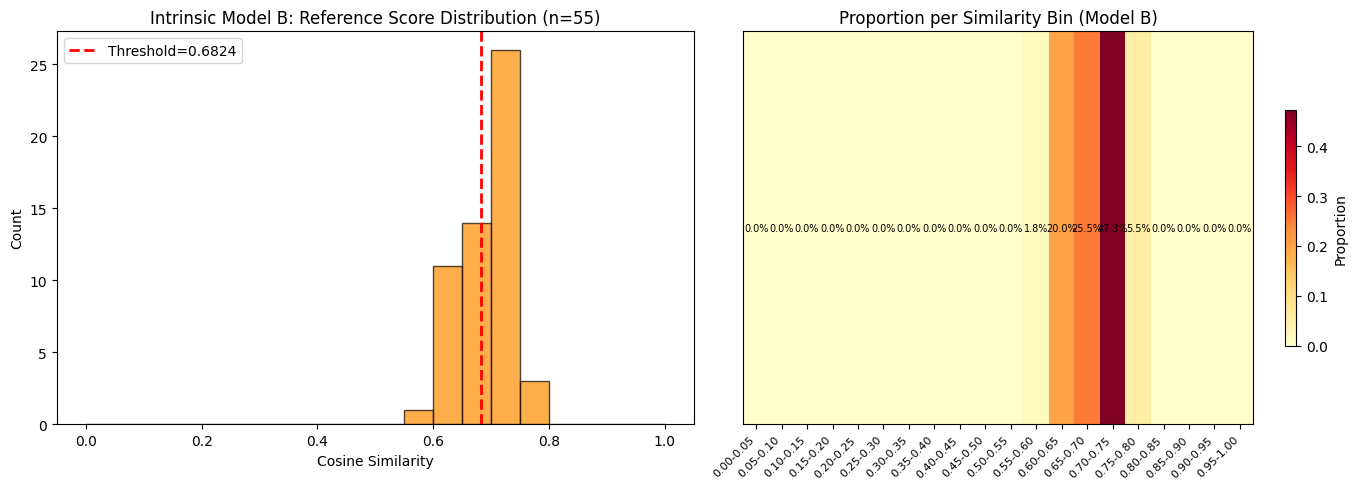

In [116]:
# --- Visualize intrinsic distribution for model B ---
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins = np.arange(0.0, 1.05, 0.05)
counts, _, patches = axes[0].hist(scores_intrinsic_b, bins=bins, edgecolor='black', alpha=0.7, color='darkorange')
axes[0].axvline(ci_low_ib, color='red', linestyle='--', linewidth=2, label=f'Threshold={ci_low_ib:.4f}')
axes[0].set_xlabel('Cosine Similarity')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Intrinsic Model B: Reference Score Distribution (n={len(scores_intrinsic_b)})')
axes[0].legend()

bin_labels = [f'{b:.2f}-{b+0.05:.2f}' for b in bins[:-1]]
proportions = counts / counts.sum()
heatmap_data = proportions.reshape(1, -1)
im = axes[1].imshow(heatmap_data, aspect='auto', cmap='YlOrRd', vmin=0)
axes[1].set_xticks(range(len(bin_labels)))
axes[1].set_xticklabels(bin_labels, rotation=45, ha='right', fontsize=8)
axes[1].set_yticks([])
axes[1].set_title('Proportion per Similarity Bin (Model B)')
for j in range(len(bin_labels)):
    axes[1].text(j, 0, f'{proportions[j]:.1%}', ha='center', va='center', fontsize=7)
fig.colorbar(im, ax=axes[1], shrink=0.6, label='Proportion')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'intrinsic_threshold_distribution_model_b.png'), dpi=150)
plt.show()

##### 3.2.1.1c Embedding Model B (bge-base): NL CVE Description vs Action Semantics 

Use `BAAI/bge-base-en-v1.5` with NL CVE description on the NL side, and **extracted action semantics** (action name + precondition predicates + effect predicates) on the PDDL side. This removes PDDL syntax noise while preserving the logical structure of each action.

In [117]:
# ---Extract attack path (concatenation of action names)---
def extract_action_names(pddl_text: str) -> str:
    """Extract action names from PDDL domain text."""
    names = re.findall(r"\(:action\s+([\w-]+)", pddl_text)
    return " ".join(names)

# ---Extract attack path with precondition and effect of each step (concatenation of action names, action preconditions, action effects)---
def extract_action_semantics(pddl_text: str) -> str:
    """Extract action name + precondition predicates + effect predicates from PDDL domain.
    Filters PDDL keywords, returns one line per action:
      action-name precondition: pred1 pred2 effect: pred3 pred4
    """
    PDDL_KEYWORDS = {
        'and', 'or', 'not', 'when', 'forall', 'exists',
        'increase', 'decrease', 'assign', 'total-cost',
    }
    blocks = re.split(r'\(:action\s+', pddl_text)
    lines = []
    for block in blocks[1:]:  # skip preamble before first action
        # action name is the first token
        name = block.split()[0] if block.split() else "unknown"
        # extract precondition predicates
        pre_match = re.search(r':precondition\s*\((.*?)\)\s*:effect', block, re.DOTALL)
        pre_preds = []
        if pre_match:
            pre_preds = [p for p in re.findall(r'\((\S+)', pre_match.group(1))
                         if p.lower() not in PDDL_KEYWORDS]
        # extract effect predicates
        eff_match = re.search(r':effect\s*\((.*)', block, re.DOTALL)
        eff_preds = []
        if eff_match:
            eff_text = eff_match.group(1)
            # balance parentheses to find end of effect
            depth = 1
            end = 0
            for i, ch in enumerate(eff_text):
                if ch == '(':
                    depth += 1
                elif ch == ')':
                    depth -= 1
                if depth == 0:
                    end = i
                    break
            eff_text = eff_text[:end]
            eff_preds = [p for p in re.findall(r'\((\S+)', eff_text)
                         if p.lower() not in PDDL_KEYWORDS]
        line = f"{name} precondition: {' '.join(pre_preds)} effect: {' '.join(eff_preds)}"
        lines.append(line)
    return "\n".join(lines)

In [118]:
# --- 3.2.1.1c: NL description vs action semantics (bge-base) ---
descriptions_c = []
action_sem_texts_c = []
labels_c = []

eval_set_path = Path(EVAL_SET_DIR)
for cve_dir in sorted(eval_set_path.iterdir()):
    if not cve_dir.is_dir():
        continue
    cve_id = cve_dir.name
    description = cve_descriptions.get(cve_id)
    if description is None:
        print(f"SKIP {cve_id}: no description in target_pool.json")
        continue
    for config_dir in sorted(cve_dir.iterdir()):
        if not config_dir.is_dir():
            continue
        domain_file = config_dir / DOMAIN_FILE
        if not domain_file.exists():
            continue
        domain = domain_file.read_text(encoding='utf-8').strip()
        action_sem = extract_action_semantics(domain)
        descriptions_c.append(description)
        action_sem_texts_c.append(action_sem)
        labels_c.append(f"{cve_id}/{config_dir.name}")

print("Example action semantics:")
print(action_sem_texts_c[0] if action_sem_texts_c else "N/A")

sim_matrix_c = embedding_similarity_intrinsic(descriptions_c, action_sem_texts_c, embedding_model_b)
emb_intrinsic_results_c = []
for i, label in enumerate(labels_c):
    sim = float(sim_matrix_c[i, i])
    emb_intrinsic_results_c.append({'label': label, 'similarity': sim})
    print(f"[3.2.1.1c] {label}  similarity: {sim:.4f}")

Example action semantics:
target-system-exposes-attack-surface-to-attackers-CVE-2022-1471 precondition: has-library snakeyaml-library < version has-api-endpoint accepts-yaml-input api-endpoint-uses-constructor api-endpoint-has-input-validation api-endpoint-has-input-type-restriction api-endpoint-uses-safeconstructor has-waf-protection has-rate-limiting effect: exposes-attack-surface exploit-by vulnerable-snakeyaml-constructor total-cost)
attacker-crafts-malicious-yaml-payload precondition: exposes-attack-surface exploit-by effect: malicious-payload malicious-yaml-payload total-cost)
attacker-sends-http-post-request-with-malicious-yaml precondition: malicious-yaml-payload has-api-endpoint exposes-attack-surface effect: http-post-request-sent malicious-payload-transmitted total-cost)
target-system-receives-http-post-request-with-malicious-yaml precondition: http-post-request-sent malicious-payload-transmitted has-api-endpoint effect: http-post-request-received total-cost)
target-system-e

In [119]:
# --- 3.2.1.1c: Bootstrap threshold (bge-base, desc, action semantics) ---
def collect_reference_scores_intrinsic_action_sem(dataset, model):
    """Compute cosine similarities for all reference (description, action semantics) pairs."""
    descs = []
    action_texts = []
    for entry in dataset:
        for ap in entry['attack_paths']:
            action_sem = extract_action_semantics(ap['domain'])
            descs.append(entry['description'])
            action_texts.append(action_sem)
    E_desc = model.encode(descs, convert_to_tensor=True, normalize_embeddings=True, show_progress_bar=False)
    E_action = model.encode(action_texts, convert_to_tensor=True, normalize_embeddings=True, show_progress_bar=False)
    scores = (E_desc * E_action).sum(dim=1).float().cpu().numpy()
    return scores


scores_intrinsic_c = collect_reference_scores_intrinsic_action_sem(dataset, embedding_model_b)
ci_low_ic, ci_high_ic, boot_means_ic = bootstrap_threshold(scores_intrinsic_c, seed=SEED)

print(f"Intrinsic threshold 3.2.1.1c (model={EMBEDDING_MODEL_NAME_B}, NL=desc, PDDL=action-semantics, n={len(scores_intrinsic_c)})")
print(f"  mean={scores_intrinsic_c.mean():.4f}  std={scores_intrinsic_c.std():.4f}  "
      f"min={scores_intrinsic_c.min():.4f}  max={scores_intrinsic_c.max():.4f}")
print(f"  95% CI of mean: [{ci_low_ic:.4f}, {ci_high_ic:.4f}]")
print(f"  Suggested threshold (CI lower bound): {ci_low_ic:.4f}")

Intrinsic threshold 3.2.1.1c (model=BAAI/bge-base-en-v1.5, NL=desc, PDDL=action-semantics, n=55)
  mean=0.7458  std=0.0411  min=0.6456  max=0.8282
  95% CI of mean: [0.7350, 0.7567]
  Suggested threshold (CI lower bound): 0.7350


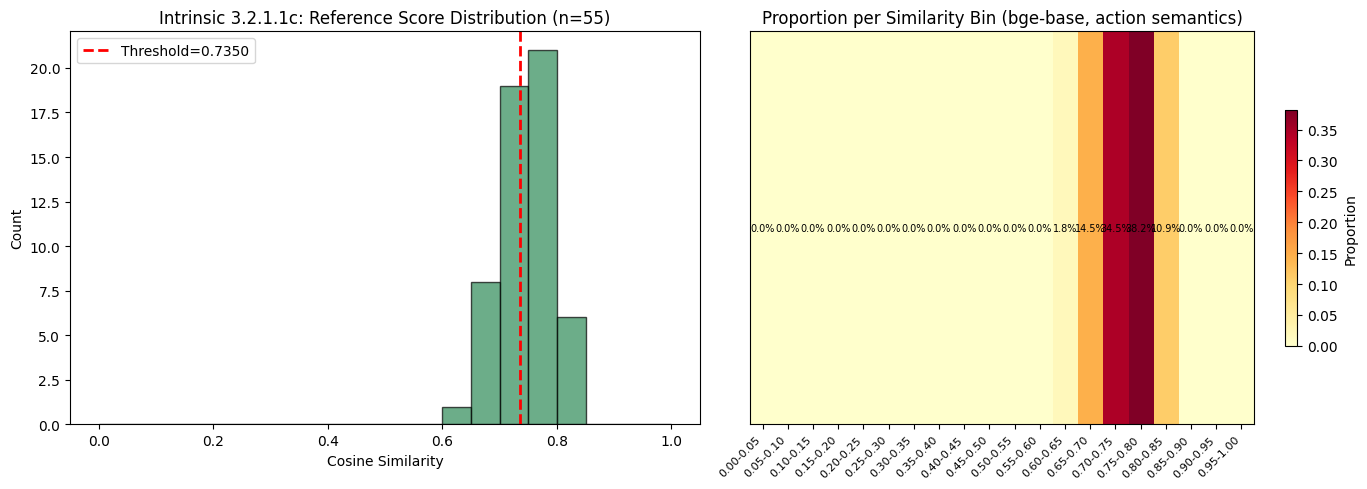

In [120]:
# --- Visualize intrinsic distribution for 3.2.1.1c (bge-base, action semantics) ---
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins = np.arange(0.0, 1.05, 0.05)
counts, _, patches = axes[0].hist(scores_intrinsic_c, bins=bins, edgecolor="black", alpha=0.7, color="seagreen")
axes[0].axvline(ci_low_ic, color="red", linestyle="--", linewidth=2, label=f"Threshold={ci_low_ic:.4f}")
axes[0].set_xlabel("Cosine Similarity")
axes[0].set_ylabel("Count")
axes[0].set_title(f"Intrinsic 3.2.1.1c: Reference Score Distribution (n={len(scores_intrinsic_c)})")
axes[0].legend()

bin_labels = [f"{b:.2f}-{b+0.05:.2f}" for b in bins[:-1]]
proportions = counts / counts.sum()
heatmap_data = proportions.reshape(1, -1)
im = axes[1].imshow(heatmap_data, aspect="auto", cmap="YlOrRd", vmin=0)
axes[1].set_xticks(range(len(bin_labels)))
axes[1].set_xticklabels(bin_labels, rotation=45, ha="right", fontsize=8)
axes[1].set_yticks([])
axes[1].set_title("Proportion per Similarity Bin (bge-base, action semantics)")
for j in range(len(bin_labels)):
    axes[1].text(j, 0, f"{proportions[j]:.1%}", ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=axes[1], shrink=0.6, label="Proportion")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "intrinsic_threshold_distribution_action_sem.png"), dpi=150)
plt.show()

##### Problem Summary
Limitations of Embedding-Based Intrinsic Evaluation                                                                                 
                                                                                                                                      
- Cosine similarity between NL vulnerability descriptions and PDDL domains seems performs worse for distinguishing good from bad attack paths. For example, using all-MiniLM-L6-v2, the reference PDDL for CVE-2022-1471 scored 0.3815, while LLM-generated outputs for CVE-2025-66032 scored comparably (GPT-4: 0.3689, Qwen-max: 0.3575). With BGE-base-en-v1.5, the problem worsened: the generated outputs (0.7720, 0.7083) even exceeded the reference (0.7166).                                                            
                                                                                                                                      
- This occurs because embedding similarity captures lexical overlap rather than logical correctness. A generated PDDL containing surface-level keywords from the CVE description (e.g., context-window, code-execution) can score as high as a structurally correct reference that uses domain-specific PDDL terms (e.g., yaml-constructor, jndi-endpoint). But the one scored high by the intrinsic similarity is worse in semantic fidebility, atomicity and completeness.

   - potential solution, augment the description with other threat intelligence (contains key information for attack)

##### 3.2.1.1d Embedding Model B (bge-base): TI-Selected NL vs Action Semantics

Use `BAAI/bge-base-en-v1.5` with **TI-selected NL** (description + CAPEC + CVSS vector) on the NL side, and **extracted action semantics** (action name + precondition predicates + effect predicates) on the PDDL side.

Block1: load threat intelligence for CVE

In [121]:
# --- 3.2.1.1d: TI-selected NL (desc+capec+cvss_vector_nl) vs action semantics (bge-base) ---
import re as _re

TARGET_POOL_TI_FILE = os.path.join(PROJECT_ROOT, "resources", "data", "target_pool_ti.json")

def load_target_pool_ti(path):
    """Load TI-enriched target pool. Returns {cve_id: {field: value}}."""
    with open(path, encoding="utf-8") as f:
        pool = json.load(f)
    return {entry["cve_id"]: entry for entry in pool}

def strip_base_score(cvss_nl):
    """Remove Base Score from CVSS vector NL string."""
    if not cvss_nl:
        return ""
    return _re.sub(r"\s*Base Score:\s*[\d.]+\.?\s*", "", cvss_nl).strip()

def build_nl_ti_selected(entry_ti):
    """Build TI-selected NL: desc + capec + cvss_vector_nl (no base score)."""
    parts = [entry_ti.get("description", "")]
    capec = entry_ti.get("capec", "")
    if capec:
        parts.append(capec)
    cvss = strip_base_score(entry_ti.get("cvss_vector_nl", ""))
    if cvss:
        parts.append(cvss)
    return " ".join(parts)

ti_pool = load_target_pool_ti(TARGET_POOL_TI_FILE)

descriptions_d = []
action_sem_texts_d = []
labels_d = []

eval_set_path = Path(EVAL_SET_DIR)
for cve_dir in sorted(eval_set_path.iterdir()):
    if not cve_dir.is_dir():
        continue
    cve_id = cve_dir.name
    ti_entry = ti_pool.get(cve_id)
    if ti_entry is None:
        print(f"SKIP {cve_id}: not in target_pool_ti.json")
        continue
    nl_ti = build_nl_ti_selected(ti_entry)
    for config_dir in sorted(cve_dir.iterdir()):
        if not config_dir.is_dir():
            continue
        domain_file = config_dir / DOMAIN_FILE
        if not domain_file.exists():
            continue
        domain = domain_file.read_text(encoding="utf-8").strip()
        action_sem = extract_action_semantics(domain)
        descriptions_d.append(nl_ti)
        action_sem_texts_d.append(action_sem)
        labels_d.append(f"{cve_id}/{config_dir.name}")

print("Example TI-selected NL (first 300 chars):")
print(descriptions_d[0][:300] if descriptions_d else "N/A")

Example TI-selected NL (first 300 chars):
SnakeYaml's Constructor() class does not restrict types which can be instantiated during deserialization. Deserializing yaml content provided by an attacker can lead to remote code execution. We recommend using SnakeYaml's SafeConsturctor when parsing untrusted content to restrict deserialization. W


In [122]:
sim_matrix_d = embedding_similarity_intrinsic(descriptions_d, action_sem_texts_d, embedding_model_b)
emb_intrinsic_results_d = []
for i, label in enumerate(labels_d):
    sim = float(sim_matrix_d[i, i])
    emb_intrinsic_results_d.append({"label": label, "similarity": sim})
    print(f"[3.2.1.1d] {label}  similarity: {sim:.4f}")

[3.2.1.1d] CVE-2022-1471/gpt41_baseline_cveonly  similarity: 0.8025
[3.2.1.1d] CVE-2022-1471/gpt41mini_ctx_feedback  similarity: 0.8084
[3.2.1.1d] CVE-2022-1471/gpt4mini_1shot_augmented  similarity: 0.7621
[3.2.1.1d] CVE-2022-1471/reference  similarity: 0.7722
[3.2.1.1d] CVE-2023-44487/gpt41mini_ctx_feedback  similarity: 0.7618
[3.2.1.1d] CVE-2023-44487/gpt41mini_feedback  similarity: 0.7353
[3.2.1.1d] CVE-2023-6378/reference  similarity: 0.7983
[3.2.1.1d] CVE-2025-24813/gpt41_ctx_feedback_v2  similarity: 0.7532
[3.2.1.1d] CVE-2025-24813/reference  similarity: 0.7501
[3.2.1.1d] CVE-2025-66032/gpt4_1shot  similarity: 0.7930
[3.2.1.1d] CVE-2025-66032/qwen-max_1shot  similarity: 0.7305


In [123]:
# --- 3.2.1.1d: Bootstrap threshold (bge-base, TI-selected NL, action semantics) ---
def collect_reference_scores_intrinsic_ti_action_sem(dataset, ti_pool, model):
    """Cosine similarities for all reference (TI-selected NL, action semantics) pairs."""
    descs = []
    action_texts = []
    for entry in dataset:
        ti_entry = ti_pool.get(entry["cve_id"])
        if ti_entry is None:
            continue
        nl_ti = build_nl_ti_selected(ti_entry)
        for ap in entry["attack_paths"]:
            action_sem = extract_action_semantics(ap["domain"])
            descs.append(nl_ti)
            action_texts.append(action_sem)
    E_desc = model.encode(descs, convert_to_tensor=True, normalize_embeddings=True, show_progress_bar=False)
    E_action = model.encode(action_texts, convert_to_tensor=True, normalize_embeddings=True, show_progress_bar=False)
    scores = (E_desc * E_action).sum(dim=1).float().cpu().numpy()
    return scores


scores_intrinsic_d = collect_reference_scores_intrinsic_ti_action_sem(dataset, ti_pool, embedding_model_b)
ci_low_id, ci_high_id, boot_means_id = bootstrap_threshold(scores_intrinsic_d, seed=SEED)

print(f"Intrinsic threshold 3.2.1.1d (model={EMBEDDING_MODEL_NAME_B}, NL=TI-selected, PDDL=action-semantics, n={len(scores_intrinsic_d)})")
print(f"  mean={scores_intrinsic_d.mean():.4f}  std={scores_intrinsic_d.std():.4f}  "
      f"min={scores_intrinsic_d.min():.4f}  max={scores_intrinsic_d.max():.4f}")
print(f"  95% CI of mean: [{ci_low_id:.4f}, {ci_high_id:.4f}]")
print(f"  Suggested threshold (CI lower bound): {ci_low_id:.4f}")

Intrinsic threshold 3.2.1.1d (model=BAAI/bge-base-en-v1.5, NL=TI-selected, PDDL=action-semantics, n=55)
  mean=0.7604  std=0.0373  min=0.6678  max=0.8399
  95% CI of mean: [0.7506, 0.7701]
  Suggested threshold (CI lower bound): 0.7506


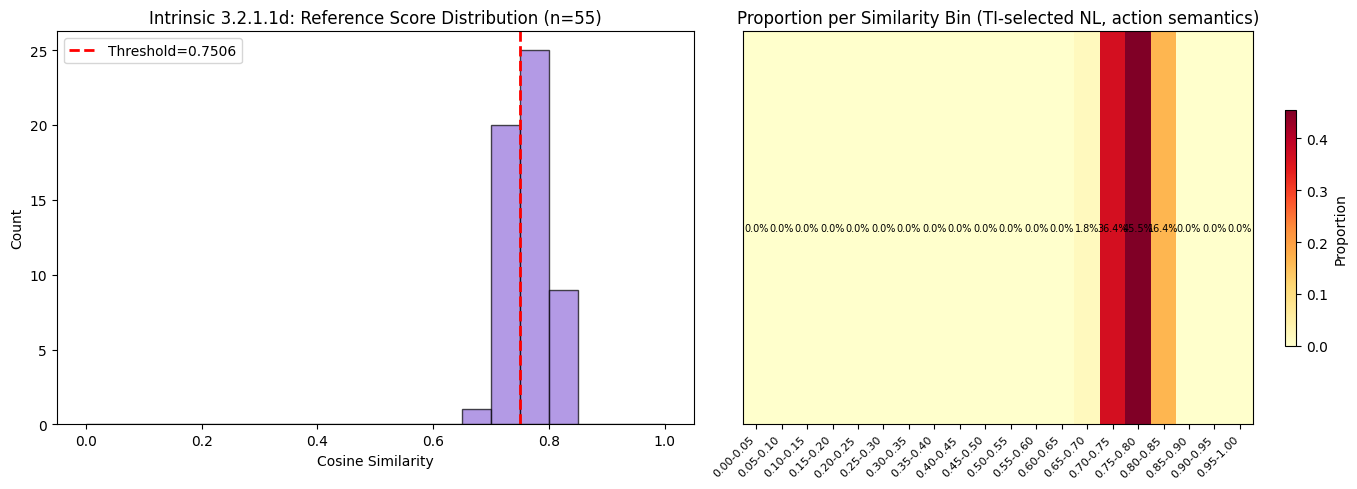

In [124]:
# --- Visualize intrinsic distribution for 3.2.1.1d (bge-base, TI-selected NL, action semantics) ---
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins = np.arange(0.0, 1.05, 0.05)
counts, _, patches = axes[0].hist(scores_intrinsic_d, bins=bins, edgecolor="black", alpha=0.7, color="mediumpurple")
axes[0].axvline(ci_low_id, color="red", linestyle="--", linewidth=2, label=f"Threshold={ci_low_id:.4f}")
axes[0].set_xlabel("Cosine Similarity")
axes[0].set_ylabel("Count")
axes[0].set_title(f"Intrinsic 3.2.1.1d: Reference Score Distribution (n={len(scores_intrinsic_d)})")
axes[0].legend()

bin_labels = [f"{b:.2f}-{b+0.05:.2f}" for b in bins[:-1]]
proportions = counts / counts.sum()
heatmap_data = proportions.reshape(1, -1)
im = axes[1].imshow(heatmap_data, aspect="auto", cmap="YlOrRd", vmin=0)
axes[1].set_xticks(range(len(bin_labels)))
axes[1].set_xticklabels(bin_labels, rotation=45, ha="right", fontsize=8)
axes[1].set_yticks([])
axes[1].set_title("Proportion per Similarity Bin (TI-selected NL, action semantics)")
for j in range(len(bin_labels)):
    axes[1].text(j, 0, f"{proportions[j]:.1%}", ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=axes[1], shrink=0.6, label="Proportion")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "intrinsic_threshold_distribution_ti_action_sem.png"), dpi=150)
plt.show()

Observations:
- The intrinsic similarity distribution of the reference AP domain becomes more concentrated after augmenting the NL CVE description with additional threat intelligence, including CAPEC and cvss_vector_nl.

##### 3.2.1.1e Embedding Model B (bge-base): TI-Selected NL vs Action Names

Use `BAAI/bge-base-en-v1.5` with **TI-selected NL** (description + CAPEC + CVSS vector) on the NL side, and **extracted action names only** (no preconditions/effects) on the PDDL side.

In [125]:
# --- 3.2.1.1e: TI-selected NL vs action names only (bge-base) ---
descriptions_e = []
action_name_texts_e = []
labels_e = []

eval_set_path = Path(EVAL_SET_DIR)
for cve_dir in sorted(eval_set_path.iterdir()):
    if not cve_dir.is_dir():
        continue
    cve_id = cve_dir.name
    ti_entry = ti_pool.get(cve_id)
    if ti_entry is None:
        print(f"SKIP {cve_id}: not in target_pool_ti.json")
        continue
    nl_ti = build_nl_ti_selected(ti_entry)
    for config_dir in sorted(cve_dir.iterdir()):
        if not config_dir.is_dir():
            continue
        domain_file = config_dir / DOMAIN_FILE
        if not domain_file.exists():
            continue
        domain = domain_file.read_text(encoding="utf-8").strip()
        action_names = extract_action_names(domain)
        descriptions_e.append(nl_ti)
        action_name_texts_e.append(action_names)
        labels_e.append(f"{cve_id}/{config_dir.name}")

print("Example action names:")
print(action_name_texts_e[0][:300] if action_name_texts_e else "N/A")

Example action names:
target-system-exposes-attack-surface-to-attackers-CVE-2022-1471 attacker-crafts-malicious-yaml-payload attacker-sends-http-post-request-with-malicious-yaml target-system-receives-http-post-request-with-malicious-yaml target-system-extracts-yaml-payload-from-http-request target-system-invokes-snakeya


In [126]:
sim_matrix_e = embedding_similarity_intrinsic(descriptions_e, action_name_texts_e, embedding_model_b)
emb_intrinsic_results_e = []
for i, label in enumerate(labels_e):
    sim = float(sim_matrix_e[i, i])
    emb_intrinsic_results_e.append({"label": label, "similarity": sim})
    print(f"[3.2.1.1e] {label}  similarity: {sim:.4f}")

[3.2.1.1e] CVE-2022-1471/gpt41_baseline_cveonly  similarity: 0.7354
[3.2.1.1e] CVE-2022-1471/gpt41mini_ctx_feedback  similarity: 0.7387
[3.2.1.1e] CVE-2022-1471/gpt4mini_1shot_augmented  similarity: 0.6954
[3.2.1.1e] CVE-2022-1471/reference  similarity: 0.7295
[3.2.1.1e] CVE-2023-44487/gpt41mini_ctx_feedback  similarity: 0.7768
[3.2.1.1e] CVE-2023-44487/gpt41mini_feedback  similarity: 0.7138
[3.2.1.1e] CVE-2023-6378/reference  similarity: 0.7428
[3.2.1.1e] CVE-2025-24813/gpt41_ctx_feedback_v2  similarity: 0.7494
[3.2.1.1e] CVE-2025-24813/reference  similarity: 0.7570
[3.2.1.1e] CVE-2025-66032/gpt4_1shot  similarity: 0.7007
[3.2.1.1e] CVE-2025-66032/qwen-max_1shot  similarity: 0.6989


In [127]:
# --- 3.2.1.1e: Bootstrap threshold (bge-base, TI-selected NL, action names) ---
def collect_reference_scores_intrinsic_ti_action_names(dataset, ti_pool, model):
    """Cosine similarities for all reference (TI-selected NL, action names) pairs."""
    descs = []
    action_texts = []
    for entry in dataset:
        ti_entry = ti_pool.get(entry["cve_id"])
        if ti_entry is None:
            continue
        nl_ti = build_nl_ti_selected(ti_entry)
        for ap in entry["attack_paths"]:
            action_names = extract_action_names(ap["domain"])
            descs.append(nl_ti)
            action_texts.append(action_names)
    E_desc = model.encode(descs, convert_to_tensor=True, normalize_embeddings=True, show_progress_bar=False)
    E_action = model.encode(action_texts, convert_to_tensor=True, normalize_embeddings=True, show_progress_bar=False)
    scores = (E_desc * E_action).sum(dim=1).float().cpu().numpy()
    return scores


scores_intrinsic_e = collect_reference_scores_intrinsic_ti_action_names(dataset, ti_pool, embedding_model_b)
ci_low_ie, ci_high_ie, boot_means_ie = bootstrap_threshold(scores_intrinsic_e, seed=SEED)

print(f"Intrinsic threshold 3.2.1.1e (model={EMBEDDING_MODEL_NAME_B}, NL=TI-selected, PDDL=action-names, n={len(scores_intrinsic_e)})")
print(f"  mean={scores_intrinsic_e.mean():.4f}  std={scores_intrinsic_e.std():.4f}  "
      f"min={scores_intrinsic_e.min():.4f}  max={scores_intrinsic_e.max():.4f}")
print(f"  95% CI of mean: [{ci_low_ie:.4f}, {ci_high_ie:.4f}]")
print(f"  Suggested threshold (CI lower bound): {ci_low_ie:.4f}")

Intrinsic threshold 3.2.1.1e (model=BAAI/bge-base-en-v1.5, NL=TI-selected, PDDL=action-names, n=55)
  mean=0.7248  std=0.0297  min=0.6444  max=0.8035
  95% CI of mean: [0.7171, 0.7328]
  Suggested threshold (CI lower bound): 0.7171


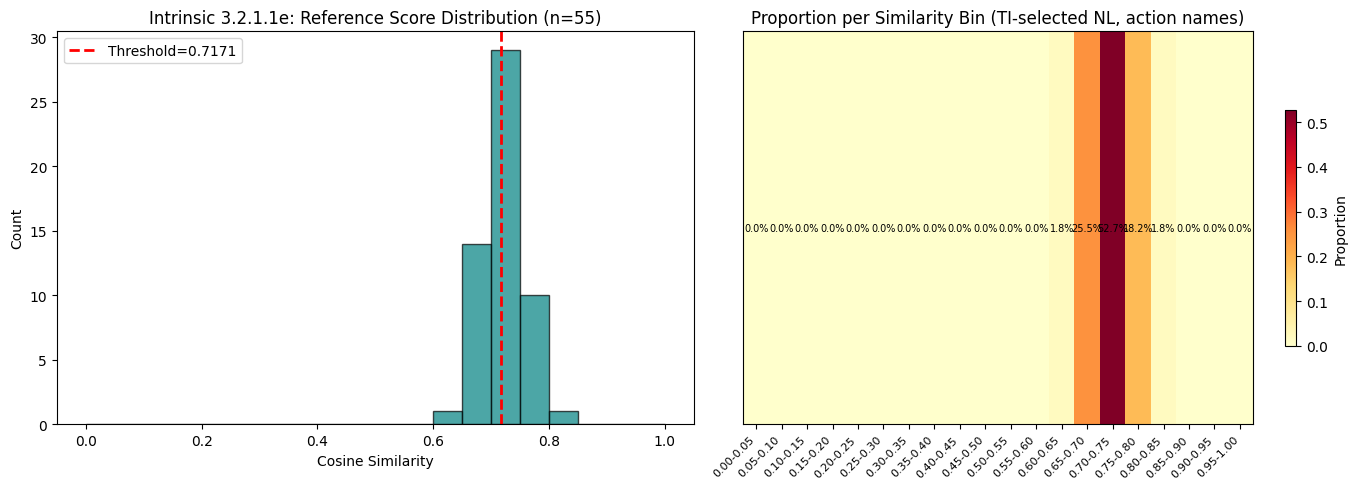

In [128]:
# --- Visualize intrinsic distribution for 3.2.1.1e (bge-base, TI-selected NL, action names) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins = np.arange(0.0, 1.05, 0.05)
counts, _, patches = axes[0].hist(scores_intrinsic_e, bins=bins, edgecolor="black", alpha=0.7, color="teal")
axes[0].axvline(ci_low_ie, color="red", linestyle="--", linewidth=2, label=f"Threshold={ci_low_ie:.4f}")
axes[0].set_xlabel("Cosine Similarity")
axes[0].set_ylabel("Count")
axes[0].set_title(f"Intrinsic 3.2.1.1e: Reference Score Distribution (n={len(scores_intrinsic_e)})")
axes[0].legend()

bin_labels = [f"{b:.2f}-{b+0.05:.2f}" for b in bins[:-1]]
proportions = counts / counts.sum()
heatmap_data = proportions.reshape(1, -1)
im = axes[1].imshow(heatmap_data, aspect="auto", cmap="YlOrRd", vmin=0)
axes[1].set_xticks(range(len(bin_labels)))
axes[1].set_xticklabels(bin_labels, rotation=45, ha="right", fontsize=8)
axes[1].set_yticks([])
axes[1].set_title("Proportion per Similarity Bin (TI-selected NL, action names)")
for j in range(len(bin_labels)):
    axes[1].text(j, 0, f"{proportions[j]:.1%}", ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=axes[1], shrink=0.6, label="Proportion")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "intrinsic_threshold_distribution_ti_action_names.png"), dpi=150)
plt.show()

##### 3.2.1.1f Embedding Model B (bge-base): TI-Selected NL vs Cumulative Per-Action Semantics

Use `BAAI/bge-base-en-v1.5` with **TI-selected NL** on the NL side. Compute **per-action cosine similarity** where each action is represented by its full semantics (name + precondition + effect), then **sum** across all actions.

In [129]:
# --- 3.2.1.1f: TI-selected NL vs cumulative per-action semantics (bge-base) ---

def cumulative_per_action_semantics_similarity(nl_text, pddl_text, model):
    """Sum of per-action cosine similarities: each action semantics (name+pre+eff) vs NL."""
    action_sem_text = extract_action_semantics(pddl_text)
    action_lines = [l.strip() for l in action_sem_text.split('\n') if l.strip()]
    if not action_lines:
        return 0.0, 0, []
    E_nl = model.encode([nl_text], convert_to_tensor=True, normalize_embeddings=True, show_progress_bar=False)
    E_actions = model.encode(action_lines, convert_to_tensor=True, normalize_embeddings=True, show_progress_bar=False)
    per_action_sims = (E_nl @ E_actions.T).squeeze(0).float().cpu().numpy()
    return float(per_action_sims.sum()), len(action_lines), per_action_sims.tolist()


emb_intrinsic_results_f = []
eval_set_path = Path(EVAL_SET_DIR)
for cve_dir in sorted(eval_set_path.iterdir()):
    if not cve_dir.is_dir():
        continue
    cve_id = cve_dir.name
    ti_entry = ti_pool.get(cve_id)
    if ti_entry is None:
        continue
    nl_ti = build_nl_ti_selected(ti_entry)
    for config_dir in sorted(cve_dir.iterdir()):
        if not config_dir.is_dir():
            continue
        domain_file = config_dir / DOMAIN_FILE
        if not domain_file.exists():
            continue
        domain = domain_file.read_text(encoding="utf-8").strip()
        cum_sim, n_actions, per_sims = cumulative_per_action_semantics_similarity(nl_ti, domain, embedding_model_b)
        label = f"{cve_id}/{config_dir.name}"
        emb_intrinsic_results_f.append({"label": label, "similarity": cum_sim, "n_actions": n_actions})
        print(f"[3.2.1.1f] {label}  cum_sim={cum_sim:.4f}  n_actions={n_actions}  mean_per_action={cum_sim/max(n_actions,1):.4f}")

[3.2.1.1f] CVE-2022-1471/gpt41_baseline_cveonly  cum_sim=5.5605  n_actions=8  mean_per_action=0.6951
[3.2.1.1f] CVE-2022-1471/gpt41mini_ctx_feedback  cum_sim=5.5130  n_actions=8  mean_per_action=0.6891
[3.2.1.1f] CVE-2022-1471/gpt4mini_1shot_augmented  cum_sim=4.2306  n_actions=6  mean_per_action=0.7051
[3.2.1.1f] CVE-2022-1471/reference  cum_sim=9.5015  n_actions=14  mean_per_action=0.6787
[3.2.1.1f] CVE-2023-44487/gpt41mini_ctx_feedback  cum_sim=6.4314  n_actions=9  mean_per_action=0.7146
[3.2.1.1f] CVE-2023-44487/gpt41mini_feedback  cum_sim=6.3314  n_actions=9  mean_per_action=0.7035
[3.2.1.1f] CVE-2023-6378/reference  cum_sim=5.6933  n_actions=8  mean_per_action=0.7117
[3.2.1.1f] CVE-2025-24813/gpt41_ctx_feedback_v2  cum_sim=4.1266  n_actions=6  mean_per_action=0.6878
[3.2.1.1f] CVE-2025-24813/reference  cum_sim=10.3917  n_actions=15  mean_per_action=0.6928
[3.2.1.1f] CVE-2025-66032/gpt4_1shot  cum_sim=2.7880  n_actions=4  mean_per_action=0.6970
[3.2.1.1f] CVE-2025-66032/qwen-max_1

In [130]:
def minmax_normalize(scores, vmin, vmax):
    return (scores - vmin) / (vmax - vmin) if vmax > vmin else scores * 0.0

# --- 3.2.1.1f: Bootstrap threshold (bge-base, TI-selected NL, cumulative per-action semantics, min-max normalized) ---
def collect_reference_scores_intrinsic_ti_cum_action_sem(dataset, ti_pool, model):
    """Cumulative per-action-semantics similarities for all reference pairs."""
    scores = []
    for entry in dataset:
        ti_entry = ti_pool.get(entry["cve_id"])
        if ti_entry is None:
            continue
        nl_ti = build_nl_ti_selected(ti_entry)
        for ap in entry["attack_paths"]:
            cum_sim, _, _ = cumulative_per_action_semantics_similarity(nl_ti, ap["domain"], model)
            scores.append(cum_sim)
    return np.array(scores)


scores_intrinsic_f_raw = collect_reference_scores_intrinsic_ti_cum_action_sem(dataset, ti_pool, embedding_model_b)

# Use reference-only min/max for normalization
cum_min_f = scores_intrinsic_f_raw.min()
cum_max_f = scores_intrinsic_f_raw.max()
print(f"Reference min-max range: [{cum_min_f:.4f}, {cum_max_f:.4f}]")

scores_intrinsic_f = minmax_normalize(scores_intrinsic_f_raw, cum_min_f, cum_max_f)

# Normalize eval-set results using reference min/max
for r in emb_intrinsic_results_f:
    r["similarity_raw"] = r["similarity"]
    r["similarity"] = float((r["similarity"] - cum_min_f) / (cum_max_f - cum_min_f))

ci_low_if, ci_high_if, boot_means_if = bootstrap_threshold(scores_intrinsic_f, seed=SEED)

print(f"Intrinsic threshold 3.2.1.1f (model={EMBEDDING_MODEL_NAME_B}, NL=TI-selected, PDDL=cum-per-action-sem, n={len(scores_intrinsic_f)})")
print(f"  mean={scores_intrinsic_f.mean():.4f}  std={scores_intrinsic_f.std():.4f}  "
      f"min={scores_intrinsic_f.min():.4f}  max={scores_intrinsic_f.max():.4f}")
print(f"  95% CI of mean: [{ci_low_if:.4f}, {ci_high_if:.4f}]")
print(f"  Suggested threshold (CI lower bound): {ci_low_if:.4f}")

Reference min-max range: [2.9804, 19.1605]
Intrinsic threshold 3.2.1.1f (model=BAAI/bge-base-en-v1.5, NL=TI-selected, PDDL=cum-per-action-sem, n=55)
  mean=0.4203  std=0.2424  min=0.0000  max=1.0000
  95% CI of mean: [0.3581, 0.4854]
  Suggested threshold (CI lower bound): 0.3581


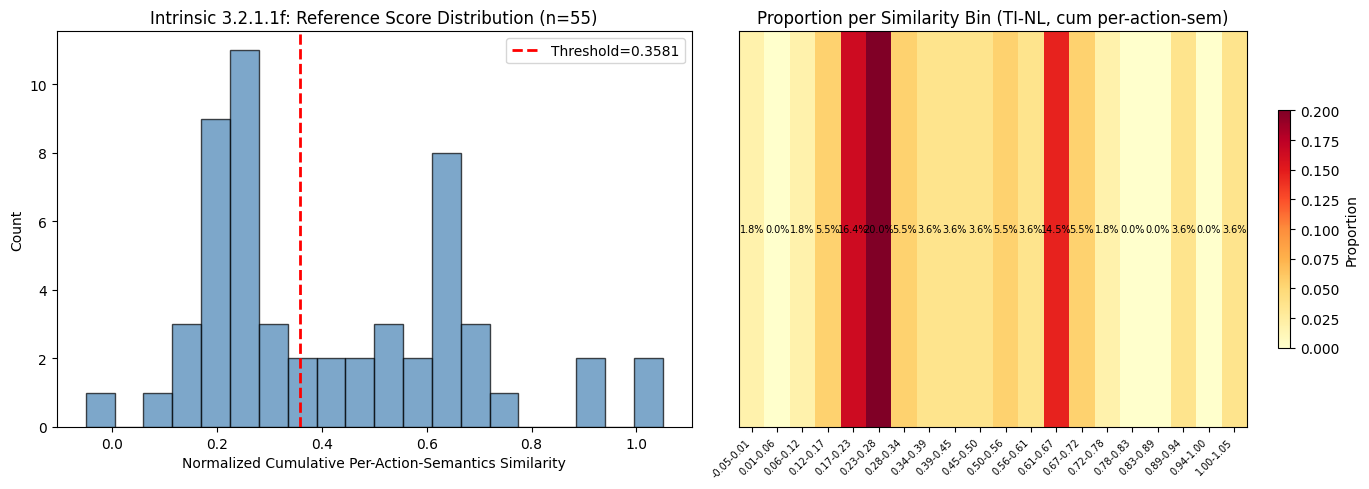

In [131]:
# --- Visualize intrinsic distribution for 3.2.1.1f (bge-base, TI-selected NL, cumulative per-action semantics) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins_e2 = np.linspace(scores_intrinsic_f.min() - 0.05, scores_intrinsic_f.max() + 0.05, 21)
counts, _, patches = axes[0].hist(scores_intrinsic_f, bins=bins_e2, edgecolor="black", alpha=0.7, color="steelblue")
axes[0].axvline(ci_low_if, color="red", linestyle="--", linewidth=2, label=f"Threshold={ci_low_if:.4f}")
axes[0].set_xlabel("Normalized Cumulative Per-Action-Semantics Similarity")
axes[0].set_ylabel("Count")
axes[0].set_title(f"Intrinsic 3.2.1.1f: Reference Score Distribution (n={len(scores_intrinsic_f)})")
axes[0].legend()

bin_labels = [f"{bins_e2[j]:.2f}-{bins_e2[j+1]:.2f}" for j in range(len(bins_e2)-1)]
proportions = counts / counts.sum()
heatmap_data = proportions.reshape(1, -1)
im = axes[1].imshow(heatmap_data, aspect="auto", cmap="YlOrRd", vmin=0)
axes[1].set_xticks(range(len(bin_labels)))
axes[1].set_xticklabels(bin_labels, rotation=45, ha="right", fontsize=7)
axes[1].set_yticks([])
axes[1].set_title("Proportion per Similarity Bin (TI-NL, cum per-action-sem)")
for j in range(len(bin_labels)):
    axes[1].text(j, 0, f"{proportions[j]:.1%}", ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=axes[1], shrink=0.6, label="Proportion")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "intrinsic_threshold_distribution_ti_cum_per_action_sem.png"), dpi=150)
plt.show()

##### 3.2.1.1j Embedding Model B (bge-base): TI-Selected NL vs Cumulative Per-Action Name Similarity

Use `BAAI/bge-base-en-v1.5` with **TI-selected NL** on the NL side. Compute **per-action cosine similarity** where each action is represented by its **name only**, then **sum** across all actions.

In [132]:
# --- 3.2.1.1j: TI-selected NL vs cumulative per-action similarity (bge-base) ---
import re as _re

def cumulative_per_action_name_similarity(nl_text, pddl_text, model):
    """Sum of per-action cosine similarities: each action name vs NL."""
    action_names = re.findall(r"\(:action\s+([\w-]+)", pddl_text)
    if not action_names:
        return 0.0, 0, []
    E_nl = model.encode([nl_text], convert_to_tensor=True, normalize_embeddings=True, show_progress_bar=False)
    E_actions = model.encode(action_names, convert_to_tensor=True, normalize_embeddings=True, show_progress_bar=False)
    per_action_sims = (E_nl @ E_actions.T).squeeze(0).float().cpu().numpy()
    return float(per_action_sims.sum()), len(action_names), per_action_sims.tolist()


emb_intrinsic_results_j = []
eval_set_path = Path(EVAL_SET_DIR)
for cve_dir in sorted(eval_set_path.iterdir()):
    if not cve_dir.is_dir():
        continue
    cve_id = cve_dir.name
    ti_entry = ti_pool.get(cve_id)
    if ti_entry is None:
        continue
    nl_ti = build_nl_ti_selected(ti_entry)
    for config_dir in sorted(cve_dir.iterdir()):
        if not config_dir.is_dir():
            continue
        domain_file = config_dir / DOMAIN_FILE
        if not domain_file.exists():
            continue
        domain = domain_file.read_text(encoding="utf-8").strip()
        cum_sim, n_actions, per_sims = cumulative_per_action_name_similarity(nl_ti, domain, embedding_model_b)
        label = f"{cve_id}/{config_dir.name}"
        emb_intrinsic_results_j.append({"label": label, "similarity": cum_sim, "n_actions": n_actions})
        print(f"[3.2.1.1j] {label}  cum_sim={cum_sim:.4f}  n_actions={n_actions}  mean_per_action={cum_sim/max(n_actions,1):.4f}")

[3.2.1.1j] CVE-2022-1471/gpt41_baseline_cveonly  cum_sim=5.4035  n_actions=8  mean_per_action=0.6754
[3.2.1.1j] CVE-2022-1471/gpt41mini_ctx_feedback  cum_sim=5.2792  n_actions=8  mean_per_action=0.6599
[3.2.1.1j] CVE-2022-1471/gpt4mini_1shot_augmented  cum_sim=4.0228  n_actions=6  mean_per_action=0.6705
[3.2.1.1j] CVE-2022-1471/reference  cum_sim=9.1525  n_actions=14  mean_per_action=0.6537
[3.2.1.1j] CVE-2023-44487/gpt41mini_ctx_feedback  cum_sim=6.1476  n_actions=9  mean_per_action=0.6831
[3.2.1.1j] CVE-2023-44487/gpt41mini_feedback  cum_sim=5.8660  n_actions=9  mean_per_action=0.6518
[3.2.1.1j] CVE-2023-6378/reference  cum_sim=5.3767  n_actions=8  mean_per_action=0.6721
[3.2.1.1j] CVE-2025-24813/gpt41_ctx_feedback_v2  cum_sim=4.0156  n_actions=6  mean_per_action=0.6693
[3.2.1.1j] CVE-2025-24813/reference  cum_sim=9.8953  n_actions=15  mean_per_action=0.6597
[3.2.1.1j] CVE-2025-66032/gpt4_1shot  cum_sim=2.6896  n_actions=4  mean_per_action=0.6724
[3.2.1.1j] CVE-2025-66032/qwen-max_1s

In [133]:
# --- 3.2.1.1j: Bootstrap threshold (bge-base, TI-selected NL, cumulative per-action, min-max normalized) ---
def collect_reference_scores_intrinsic_ti_cumulative(dataset, ti_pool, model):
    """Cumulative per-action similarities for all reference pairs."""
    scores = []
    for entry in dataset:
        ti_entry = ti_pool.get(entry["cve_id"])
        if ti_entry is None:
            continue
        nl_ti = build_nl_ti_selected(ti_entry)
        for ap in entry["attack_paths"]:
            cum_sim, _, _ = cumulative_per_action_name_similarity(nl_ti, ap["domain"], model)
            scores.append(cum_sim)
    return np.array(scores)


scores_intrinsic_j_raw = collect_reference_scores_intrinsic_ti_cumulative(dataset, ti_pool, embedding_model_b)

# Use reference-only min/max for normalization
cum_min_j = scores_intrinsic_j_raw.min()
cum_max_j = scores_intrinsic_j_raw.max()
print(f"Reference min-max range: [{cum_min_j:.4f}, {cum_max_j:.4f}]")

def minmax_normalize(scores, vmin, vmax):
    return (scores - vmin) / (vmax - vmin) if vmax > vmin else scores * 0.0

scores_intrinsic_j = minmax_normalize(scores_intrinsic_j_raw, cum_min_j, cum_max_j)

# Normalize eval-set results using reference min/max (may fall outside [0,1])
for r in emb_intrinsic_results_j:
    r["similarity_raw"] = r["similarity"]
    r["similarity"] = float((r["similarity"] - cum_min_j) / (cum_max_j - cum_min_j))

ci_low_ij, ci_high_ij, boot_means_ij = bootstrap_threshold(scores_intrinsic_j, seed=SEED)

print(f"Intrinsic threshold 3.2.1.1j (model={EMBEDDING_MODEL_NAME_B}, NL=TI-selected, PDDL=cum-per-action-normed, n={len(scores_intrinsic_j)})")
print(f"  mean={scores_intrinsic_j.mean():.4f}  std={scores_intrinsic_j.std():.4f}  "
      f"min={scores_intrinsic_j.min():.4f}  max={scores_intrinsic_j.max():.4f}")
print(f"  95% CI of mean: [{ci_low_ij:.4f}, {ci_high_ij:.4f}]")
print(f"  Suggested threshold (CI lower bound): {ci_low_ij:.4f}")

Reference min-max range: [2.8308, 18.6413]
Intrinsic threshold 3.2.1.1j (model=BAAI/bge-base-en-v1.5, NL=TI-selected, PDDL=cum-per-action-normed, n=55)
  mean=0.4021  std=0.2396  min=0.0000  max=1.0000
  95% CI of mean: [0.3408, 0.4669]
  Suggested threshold (CI lower bound): 0.3408


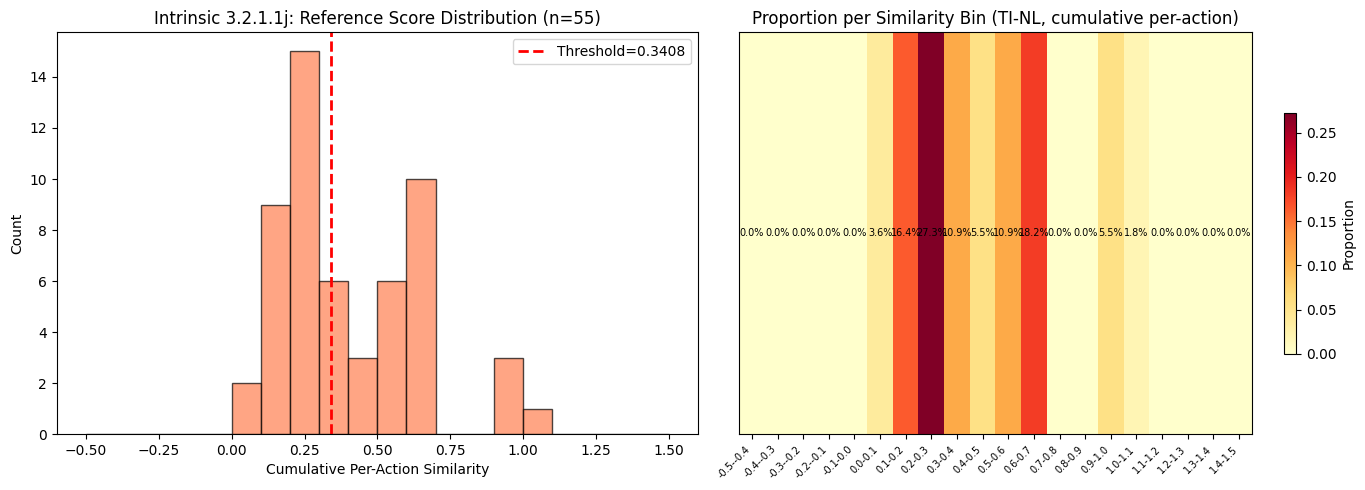

In [134]:
# --- Visualize intrinsic distribution for 3.2.1.1j (bge-base, TI-selected NL, cumulative per-action) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins_f = np.linspace(scores_intrinsic_j.min() - 0.5, scores_intrinsic_j.max() + 0.5, 21)
counts, _, patches = axes[0].hist(scores_intrinsic_j, bins=bins_f, edgecolor="black", alpha=0.7, color="coral")
axes[0].axvline(ci_low_ij, color="red", linestyle="--", linewidth=2, label=f"Threshold={ci_low_ij:.4f}")
axes[0].set_xlabel("Cumulative Per-Action Similarity")
axes[0].set_ylabel("Count")
axes[0].set_title(f"Intrinsic 3.2.1.1j: Reference Score Distribution (n={len(scores_intrinsic_j)})")
axes[0].legend()

bin_labels = [f"{bins_f[j]:.1f}-{bins_f[j+1]:.1f}" for j in range(len(bins_f)-1)]
proportions = counts / counts.sum()
heatmap_data = proportions.reshape(1, -1)
im = axes[1].imshow(heatmap_data, aspect="auto", cmap="YlOrRd", vmin=0)
axes[1].set_xticks(range(len(bin_labels)))
axes[1].set_xticklabels(bin_labels, rotation=45, ha="right", fontsize=7)
axes[1].set_yticks([])
axes[1].set_title("Proportion per Similarity Bin (TI-NL, cumulative per-action)")
for j in range(len(bin_labels)):
    axes[1].text(j, 0, f"{proportions[j]:.1%}", ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=axes[1], shrink=0.6, label="Proportion")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "intrinsic_threshold_distribution_ti_cumulative_per_action.png"), dpi=150)
plt.show()

##### 3.2.1.1h Embedding Model B (bge-base): CVE-NL vs Cumulative Per-Action Semantics

Use `BAAI/bge-base-en-v1.5` with **CVE description only** (no TI enrichment) on the NL side. Compute **per-action cosine similarity** where each action is represented by its full semantics (name + precondition + effect), then **sum** across all actions. Compare with 3.2.1.1f (TI-NL) to measure the impact of TI enrichment on cumulative similarity.

In [135]:
# --- 3.2.1.1h: CVE-NL vs cumulative per-action semantics (bge-base) ---

emb_intrinsic_results_h = []
eval_set_path = Path(EVAL_SET_DIR)
for cve_dir in sorted(eval_set_path.iterdir()):
    if not cve_dir.is_dir():
        continue
    cve_id = cve_dir.name
    description = cve_descriptions.get(cve_id)
    if description is None:
        continue
    for config_dir in sorted(cve_dir.iterdir()):
        if not config_dir.is_dir():
            continue
        domain_file = config_dir / DOMAIN_FILE
        if not domain_file.exists():
            continue
        domain = domain_file.read_text(encoding="utf-8").strip()
        cum_sim, n_actions, per_sims = cumulative_per_action_semantics_similarity(description, domain, embedding_model_b)
        label = f"{cve_id}/{config_dir.name}"
        emb_intrinsic_results_h.append({"label": label, "similarity": cum_sim, "n_actions": n_actions})
        print(f"[3.2.1.1h] {label}  cum_sim={cum_sim:.4f}  n_actions={n_actions}  mean_per_action={cum_sim/max(n_actions,1):.4f}")

[3.2.1.1h] CVE-2022-1471/gpt41_baseline_cveonly  cum_sim=5.3571  n_actions=8  mean_per_action=0.6696
[3.2.1.1h] CVE-2022-1471/gpt41mini_ctx_feedback  cum_sim=5.3477  n_actions=8  mean_per_action=0.6685
[3.2.1.1h] CVE-2022-1471/gpt4mini_1shot_augmented  cum_sim=4.0512  n_actions=6  mean_per_action=0.6752
[3.2.1.1h] CVE-2022-1471/reference  cum_sim=9.1776  n_actions=14  mean_per_action=0.6555
[3.2.1.1h] CVE-2023-44487/gpt41mini_ctx_feedback  cum_sim=5.9313  n_actions=9  mean_per_action=0.6590
[3.2.1.1h] CVE-2023-44487/gpt41mini_feedback  cum_sim=5.7305  n_actions=9  mean_per_action=0.6367
[3.2.1.1h] CVE-2023-6378/reference  cum_sim=5.4862  n_actions=8  mean_per_action=0.6858
[3.2.1.1h] CVE-2025-24813/gpt41_ctx_feedback_v2  cum_sim=4.2334  n_actions=6  mean_per_action=0.7056
[3.2.1.1h] CVE-2025-24813/reference  cum_sim=10.7266  n_actions=15  mean_per_action=0.7151
[3.2.1.1h] CVE-2025-66032/gpt4_1shot  cum_sim=2.5842  n_actions=4  mean_per_action=0.6460
[3.2.1.1h] CVE-2025-66032/qwen-max_1

In [136]:
# --- 3.2.1.1h: Bootstrap threshold (bge-base, CVE-NL, cumulative per-action semantics, min-max normalized) ---
def collect_reference_scores_intrinsic_desc_cum_action_sem(dataset, model):
    """Cumulative per-action-semantics similarities for all reference pairs (CVE desc only)."""
    scores = []
    for entry in dataset:
        for ap in entry["attack_paths"]:
            cum_sim, _, _ = cumulative_per_action_semantics_similarity(entry["description"], ap["domain"], model)
            scores.append(cum_sim)
    return np.array(scores)


scores_intrinsic_h_raw = collect_reference_scores_intrinsic_desc_cum_action_sem(dataset, embedding_model_b)

# Use reference-only min/max for normalization
cum_min_h = scores_intrinsic_h_raw.min()
cum_max_h = scores_intrinsic_h_raw.max()
print(f"Reference min-max range: [{cum_min_h:.4f}, {cum_max_h:.4f}]")

scores_intrinsic_h = minmax_normalize(scores_intrinsic_h_raw, cum_min_h, cum_max_h)

# Normalize eval-set results using reference min/max
for r in emb_intrinsic_results_h:
    r["similarity_raw"] = r["similarity"]
    r["similarity"] = float((r["similarity"] - cum_min_h) / (cum_max_h - cum_min_h))

ci_low_ih, ci_high_ih, boot_means_ih = bootstrap_threshold(scores_intrinsic_h, seed=SEED)

print(f"Intrinsic threshold 3.2.1.1h (model={EMBEDDING_MODEL_NAME_B}, NL=CVE-desc, PDDL=cum-per-action-sem, n={len(scores_intrinsic_h)})")
print(f"  mean={scores_intrinsic_h.mean():.4f}  std={scores_intrinsic_h.std():.4f}  "
      f"min={scores_intrinsic_h.min():.4f}  max={scores_intrinsic_h.max():.4f}")
print(f"  95% CI of mean: [{ci_low_ih:.4f}, {ci_high_ih:.4f}]")
print(f"  Suggested threshold (CI lower bound): {ci_low_ih:.4f}")

Reference min-max range: [2.8762, 17.8794]
Intrinsic threshold 3.2.1.1h (model=BAAI/bge-base-en-v1.5, NL=CVE-desc, PDDL=cum-per-action-sem, n=55)
  mean=0.4461  std=0.2482  min=0.0000  max=1.0000
  95% CI of mean: [0.3822, 0.5126]
  Suggested threshold (CI lower bound): 0.3822


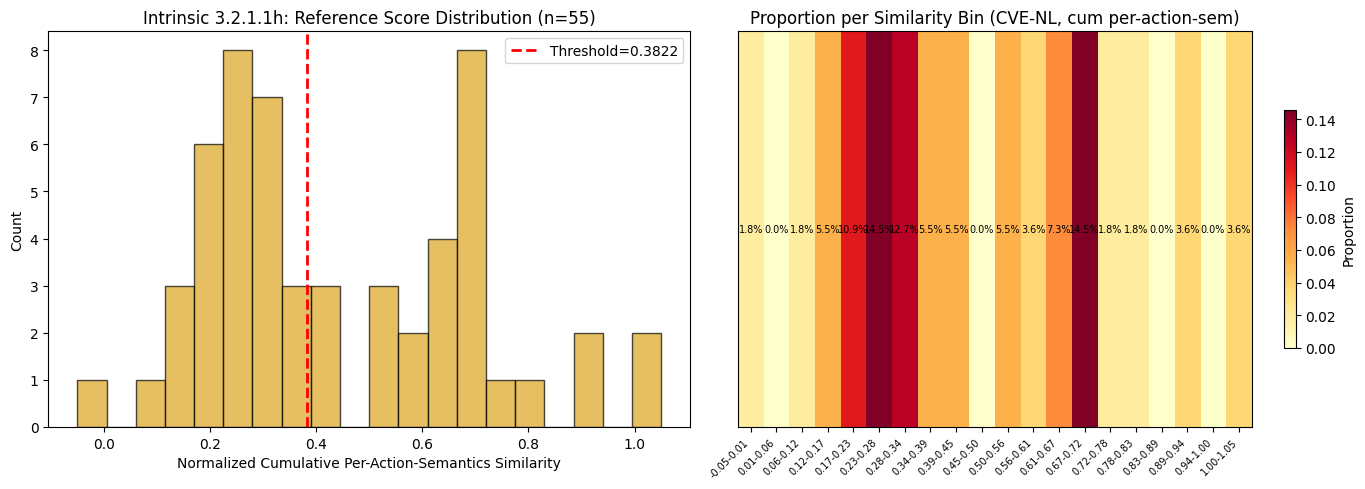

In [137]:
# --- Visualize intrinsic distribution for 3.2.1.1h (bge-base, CVE-NL, cumulative per-action semantics) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins_h = np.linspace(scores_intrinsic_h.min() - 0.05, scores_intrinsic_h.max() + 0.05, 21)
counts, _, patches = axes[0].hist(scores_intrinsic_h, bins=bins_h, edgecolor="black", alpha=0.7, color="goldenrod")
axes[0].axvline(ci_low_ih, color="red", linestyle="--", linewidth=2, label=f"Threshold={ci_low_ih:.4f}")
axes[0].set_xlabel("Normalized Cumulative Per-Action-Semantics Similarity")
axes[0].set_ylabel("Count")
axes[0].set_title(f"Intrinsic 3.2.1.1h: Reference Score Distribution (n={len(scores_intrinsic_h)})")
axes[0].legend()

bin_labels = [f"{bins_h[j]:.2f}-{bins_h[j+1]:.2f}" for j in range(len(bins_h)-1)]
proportions = counts / counts.sum()
heatmap_data = proportions.reshape(1, -1)
im = axes[1].imshow(heatmap_data, aspect="auto", cmap="YlOrRd", vmin=0)
axes[1].set_xticks(range(len(bin_labels)))
axes[1].set_xticklabels(bin_labels, rotation=45, ha="right", fontsize=7)
axes[1].set_yticks([])
axes[1].set_title("Proportion per Similarity Bin (CVE-NL, cum per-action-sem)")
for j in range(len(bin_labels)):
    axes[1].text(j, 0, f"{proportions[j]:.1%}", ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=axes[1], shrink=0.6, label="Proportion")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "intrinsic_threshold_distribution_desc_cum_per_action_sem.png"), dpi=150)
plt.show()

##### Spot-check similarities under each variant

In [138]:
# --- Spot-check similarities under each variant ---
spot_labels = sorted(set(r["label"] for r in emb_intrinsic_results))
spot_results = {
    "3.2.1.1":  {r["label"]: r["similarity"] for r in emb_intrinsic_results},
    "3.2.1.1b": {r["label"]: r["similarity"] for r in emb_intrinsic_results_b},
    "3.2.1.1c": {r["label"]: r["similarity"] for r in emb_intrinsic_results_c},
    "3.2.1.1d": {r["label"]: r["similarity"] for r in emb_intrinsic_results_d},
    "3.2.1.1e": {r["label"]: r["similarity"] for r in emb_intrinsic_results_e},
    "3.2.1.1f": {r["label"]: r["similarity"] for r in emb_intrinsic_results_f},
    "3.2.1.1j": {r["label"]: r["similarity"] for r in emb_intrinsic_results_j},
    "3.2.1.1h": {r["label"]: r["similarity"] for r in emb_intrinsic_results_h},
}

variants = [
    ("3.2.1.1",  "MiniLM, desc, full PDDL",              scores_intrinsic,    ci_low_i),
    ("3.2.1.1b", "bge-base, desc, full PDDL",             scores_intrinsic_b,  ci_low_ib),
    ("3.2.1.1c", "bge-base, desc, action-semantics",      scores_intrinsic_c,  ci_low_ic),
    ("3.2.1.1d", "bge-base, TI-NL, action-semantics",     scores_intrinsic_d,  ci_low_id),
    ("3.2.1.1e", "bge-base, TI-NL, action-names",         scores_intrinsic_e,  ci_low_ie),
    ("3.2.1.1f", "bge-base, TI-NL, cum-per-action-sem",   scores_intrinsic_f,  ci_low_if),
    ("3.2.1.1j", "bge-base, TI-NL, cum-per-action-name",  scores_intrinsic_j,  ci_low_ij),
    ("3.2.1.1h", "bge-base, desc, cum-per-action-sem",    scores_intrinsic_h,  ci_low_ih),
]

print("--- Full Comparison (with spot-check) ---")
for key, desc, scores, thr in variants:
    print(f"  {key:11s} ({desc}):")
    print(f"    mean={scores.mean():.4f}  threshold={thr:.4f}")
    sims = spot_results[key]
    for label in spot_labels:
        sim = sims.get(label)
        if sim is None:
            continue
        status = "PASS" if sim >= thr else "BELOW"
        print(f"      {label:40s} sim={sim:.4f}  [{status}]")

--- Full Comparison (with spot-check) ---
  3.2.1.1     (MiniLM, desc, full PDDL):
    mean=0.4252  threshold=0.4000
      CVE-2022-1471/gpt41_baseline_cveonly     sim=0.3316  [BELOW]
      CVE-2022-1471/gpt41mini_ctx_feedback     sim=0.3025  [BELOW]
      CVE-2022-1471/gpt4mini_1shot_augmented   sim=0.2657  [BELOW]
      CVE-2022-1471/reference                  sim=0.3815  [BELOW]
      CVE-2023-44487/gpt41mini_ctx_feedback    sim=0.4157  [PASS]
      CVE-2023-44487/gpt41mini_feedback        sim=0.3638  [BELOW]
      CVE-2023-6378/reference                  sim=0.4221  [PASS]
      CVE-2025-24813/gpt41_ctx_feedback_v2     sim=0.5906  [PASS]
      CVE-2025-24813/reference                 sim=0.6422  [PASS]
      CVE-2025-66032/gpt4_1shot                sim=0.3689  [BELOW]
      CVE-2025-66032/qwen-max_1shot            sim=0.3575  [BELOW]
  3.2.1.1b    (bge-base, desc, full PDDL):
    mean=0.6954  threshold=0.6824
      CVE-2022-1471/gpt41_baseline_cveonly     sim=0.6716  [BELOW]
      

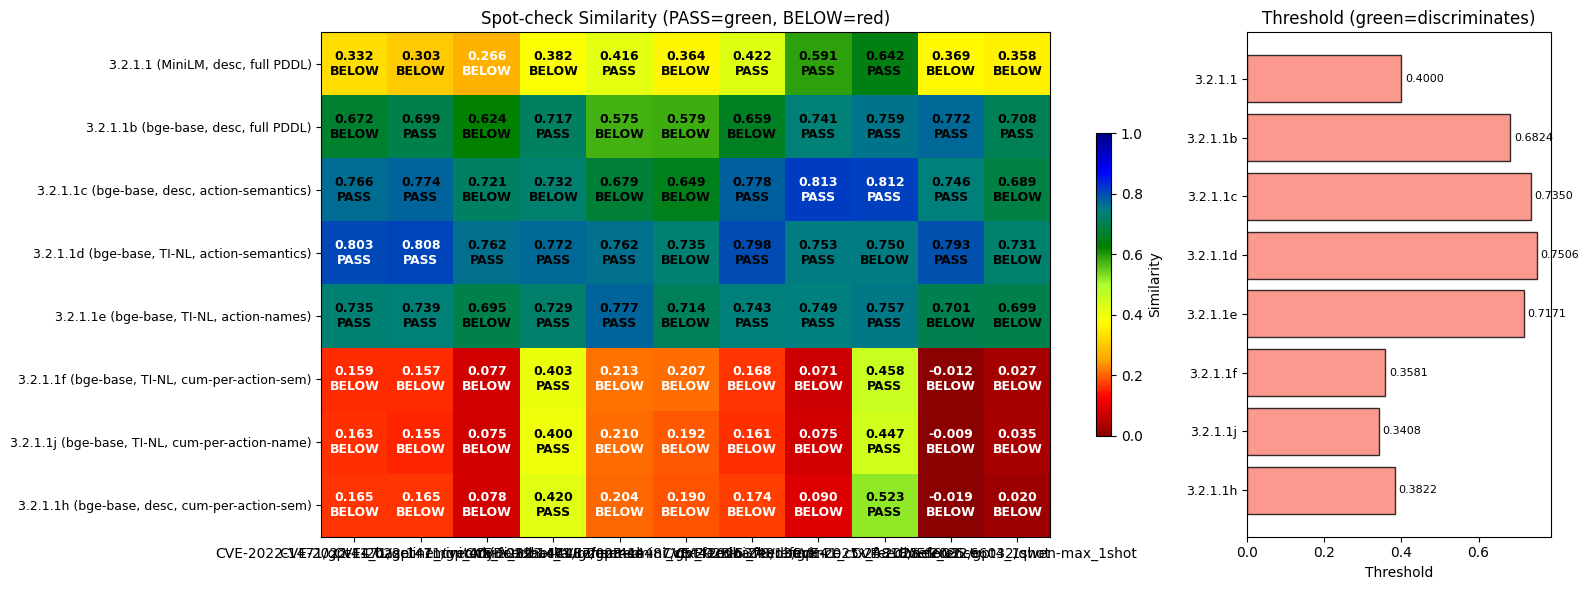

In [139]:
# --- Visualization: Full Comparison heatmap ---
import matplotlib.pyplot as plt
import numpy as np

spot_labels = sorted(set(r["label"] for r in emb_intrinsic_results))
short_labels = ["/".join(l.split("/")[-2:]) if "/" in l else l for l in spot_labels]

variant_keys = [v[0] for v in variants]
variant_descs = [v[1] for v in variants]
variant_thresholds = [v[3] for v in variants]

# Build matrix: rows=variants, cols=spot-check samples
sim_matrix = np.full((len(variants), len(spot_labels)), np.nan)
pass_matrix = np.full((len(variants), len(spot_labels)), False)

for r, (key, desc, scores, thr) in enumerate(variants):
    sims = spot_results[key]
    for c, label in enumerate(spot_labels):
        sim = sims.get(label)
        if sim is not None:
            sim_matrix[r, c] = sim
            pass_matrix[r, c] = sim >= thr

fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [3, 1]})

# Left: heatmap of similarities with PASS/BELOW annotation
from matplotlib.colors import LinearSegmentedColormap
cmap_rgbu = LinearSegmentedColormap.from_list("red_green_blue", ["darkred", "red", "orange", "yellow", "greenyellow", "green", "teal", "blue", "darkblue"])
im = axes[0].imshow(sim_matrix, cmap=cmap_rgbu, aspect="auto", vmin=0.0, vmax=1.0)
axes[0].set_xticks(range(len(short_labels)))
axes[0].set_xticklabels(short_labels, fontsize=10)
axes[0].set_yticks(range(len(variants)))
axes[0].set_yticklabels([f"{k} ({d})" for k, d in zip(variant_keys, variant_descs)], fontsize=9)
axes[0].set_title("Spot-check Similarity (PASS=green, BELOW=red)", fontsize=12)

for r in range(len(variants)):
    for c in range(len(spot_labels)):
        val = sim_matrix[r, c]
        if np.isnan(val):
            continue
        status = "PASS" if pass_matrix[r, c] else "BELOW"
        color = "black" if 0.3 < val < 0.8 else "white"
        axes[0].text(c, r, f"{val:.3f}\n{status}", ha="center", va="center", fontsize=9, fontweight="bold", color=color)

fig.colorbar(im, ax=axes[0], shrink=0.6, label="Similarity")

# Right: bar chart of thresholds and whether the variant can discriminate
# A variant "discriminates" if reference=PASS and all generated=BELOW
can_discriminate = []
for r in range(len(variants)):
    ref_pass = pass_matrix[r, 0]  # reference
    gen_below = all(not pass_matrix[r, c] for c in range(1, len(spot_labels)))
    can_discriminate.append(ref_pass and gen_below)

colors = ["seagreen" if d else "salmon" for d in can_discriminate]
bars = axes[1].barh(range(len(variants)), variant_thresholds, color=colors, edgecolor="black", alpha=0.8)
axes[1].set_yticks(range(len(variants)))
axes[1].set_yticklabels([k for k in variant_keys], fontsize=9)
axes[1].set_xlabel("Threshold", fontsize=10)
axes[1].set_title("Threshold (green=discriminates)", fontsize=12)
axes[1].invert_yaxis()

for r, thr in enumerate(variant_thresholds):
    axes[1].text(thr + 0.01, r, f"{thr:.4f}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "full_comparison_spot_check.png"), dpi=150, bbox_inches="tight")
plt.show()

###### Observations

There are three variables:
- **NL side**: CVE description only vs TI-enriched (description + CAPEC + CVSS vector NL)
- **PDDL side**: full domain+problem vs concatenated action names vs concatenated action semantics (action name + precondition predicates + effect predicates)
- **Calculation**: holistic (single embedding per AP) vs accumulated per-action similarity

Results (comparing only non-accumulated variants, where distribution shape is meaningful):
- `BAAI/bge-base-en-v1.5` produces a more concentrated reference similarity distribution than `all-MiniLM-L6-v2`
- Using extracted action names or action semantics instead of full domain+problem (which includes syntactic noise like `:types`, `:constants`, `:predicates`, and problem definitions) produces a more concentrated reference similarity distribution
- Enriching the NL side with threat intelligence (CAPEC + CVSS vector) further concentrates the distribution
- However, without accumulating per-action similarity, only **3.2.1.1e** (bge-base, TI-NL, action-names) can correctly distinguish the reference AP domain from the generated AP domain, and the difference is very trivial (reference sim=0.7295 vs threshold=0.7171, gap=0.012)

Results for accumulated variants (3.2.1.1f, 3.2.1.1j, 3.2.1.1h, normalization based on the reference distribution):
- Can distinguish reference and generated AP domain, and enlarge the positive difference between the reference and threshold, vice versa
- Reasons for calculating the accumulation:
  - Inspired by the paper "Plan in the Dark"
  - A moderately longer AP is preferable to a very short AP (only 2-3 steps). LLMs prone to generate shorter AP. By this way, the additional length information can be preserved in the similarity measure
  - For longer APs, the semantics are distributed across more actions, resulting in lower similarity for each individual action; however, the accumulated similarity better reflects the overall representation of the complete AP
  - The semantic overlap between sequential actions is indeed low, each action contributes incremental information rather than causing repeated counting. Each step performs a different operation, such as crafting a payload -> sending a request -> deserializing -> executing
  - After concatenation, the embedding model has to compress multiple semantically distinct actions into one vector, which can introduce interference among them. In contrast, accumulation allows each action to contribute to the similarity score independently

##### 3.2.1.2 LLM as an Expert: NL CVE Description vs PDDL Match

##### 3.2.1.2a TURE/FALSE
`llm_eval_intrinsic_binary`: generic classification using `llm_intrinsic_binary.jinja`(True/False)


Block 1: the function to prompt an LLM 

In [140]:
intrinsic_binary_template = prompt_env.get_template("llm_intrinsic_binary.jinja")

def llm_eval_intrinsic_binary(cve_id, description, domain, problem, client, model, seed=42):
    """Binary True/False classification: does the PDDL match the CVE?"""
    prompt = intrinsic_binary_template.render(
        cve_id=cve_id, description=description, domain=domain, problem=problem
    )
    resp = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        temperature=0.0,
        max_tokens=512,
        seed=seed,
    )
    return resp.choices[0].message.content


 Block 2: call the function with the code and the specifications from the data set

In [141]:
# llm_intrinsic_results = []
# eval_set_path = Path(EVAL_SET_DIR)
# for cve_dir in sorted(eval_set_path.iterdir()):
#     if not cve_dir.is_dir():
#         continue
#     cve_id = cve_dir.name
#     description = cve_descriptions.get(cve_id)
#     if description is None:
#         print(f"SKIP {cve_id}: no description in target_pool.json")
#         continue
#     for config_dir in sorted(cve_dir.iterdir()):
#         if not config_dir.is_dir():
#             continue
#         domain_file = config_dir / DOMAIN_FILE
#         problem_file = config_dir / PROBLEM_FILE
#         if not domain_file.exists():
#             continue
#         domain = domain_file.read_text(encoding='utf-8').strip()
#         problem = problem_file.read_text(encoding='utf-8').strip() if problem_file.exists() else ''
#         response = llm_eval_intrinsic(description, domain, problem, llm)
#         llm_intrinsic_results.append({
#             'cve_id': cve_id,
#             'config': config_dir.name,
#             'llm_response': response,
#         })
#         print(f"{cve_id}/{config_dir.name}  response: {response}")

Because waiting more than 200ms didn’t work, add the free Qwen model to quickly validate the pipeline.

In [142]:
from openai import OpenAI

nvidia = OpenAI(
    api_key=os.getenv("NVIDIA_API_KEY"),
    base_url="https://integrate.api.nvidia.com/v1",
    timeout=120.0,
)

llm_intrinsic_binary_results = []
eval_set_path = Path(EVAL_SET_DIR)
for cve_dir in sorted(eval_set_path.iterdir()):
    if not cve_dir.is_dir():
        continue
    cve_id = cve_dir.name
    description = cve_descriptions.get(cve_id)
    if description is None:
        print(f"SKIP {cve_id}: no description in target_pool.json")
        continue
    for config_dir in sorted(cve_dir.iterdir()):
        if not config_dir.is_dir():
            continue
        domain_file = config_dir / DOMAIN_FILE
        problem_file = config_dir / PROBLEM_FILE
        if not domain_file.exists():
            continue
        domain = domain_file.read_text(encoding="utf-8").strip()
        problem = problem_file.read_text(encoding="utf-8").strip() if problem_file.exists() else ""
        response = llm_eval_intrinsic_binary(cve_id, description, domain, problem, nvidia, NVIDIA_MODEL, seed=SEED)
        result = {"cve_id": cve_id, "config": config_dir.name, "llm_response": response}
        llm_intrinsic_binary_results.append(result)
        (config_dir / "llm_intrinsic_binary.json").write_text(json.dumps(result, indent=2), encoding="utf-8")
        # Parse label from response
        try:
            text = response.strip()
            if text.startswith("```"): text = text.split("\n", 1)[1].rsplit("```", 1)[0]
            label = json.loads(text).get("label", "?")
        except Exception:
            label = "?"
        print(f"{cve_id}/{config_dir.name:30s} | {label}")


CVE-2022-1471/gpt41_baseline_cveonly         | True
CVE-2022-1471/gpt41mini_ctx_feedback         | True
CVE-2022-1471/gpt4mini_1shot_augmented       | True
CVE-2022-1471/reference                      | True
CVE-2023-44487/gpt41mini_ctx_feedback         | True
CVE-2023-44487/gpt41mini_feedback             | True
CVE-2023-6378/reference                      | True
CVE-2025-24813/gpt41_ctx_feedback_v2          | True
CVE-2025-24813/reference                      | True
CVE-2025-66032/gpt4_1shot                     | True
CVE-2025-66032/qwen-max_1shot                 | True


##### 3.2.1.2b Sophisticated Intrinsic Evaluation Prompt
`llm_eval_intrinsic_scored`: sophisticated evaluation using `llm_intrinsic.jinja` (10-criteria Likert 1-5)

Block 1: the function to prompt an LLM with the 10-criteria scoring rubric

In [143]:
intrinsic_scored_template = prompt_env.get_template("llm_intrinsic.jinja")

def llm_eval_intrinsic_scored(cve_id, description, domain, problem, client, model, seed=42):
    """Sophisticated 10-criteria Likert 1-5 evaluation."""
    prompt = intrinsic_scored_template.render(
        cve_id=cve_id, description=description, domain=domain, problem=problem
    )
    resp = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        temperature=0.0,
        max_tokens=4096,
        seed=seed,
    )
    return resp.choices[0].message.content

Block 2: evaluation result parser and formatter

In [144]:
def parse_scored_response(response_text):
    """Parse LLM scored response JSON, extract scores."""
    try:
        # Strip markdown fences if present
        text = response_text.strip()
        if text.startswith("```"):
            text = text.split("\n", 1)[1]
            text = text.rsplit("```", 1)[0]
        data = json.loads(text)
        return data
    except Exception:
        return None

def summarize_intrinsic_scored(result):
    """Extract one-line summary from intrinsic scored result."""
    data = parse_scored_response(result["llm_response"])
    if data is None:
        return f"{result['cve_id']}/{result['config']}  PARSE_ERROR"
    # For action-level, compute mean from actions array
    actions = data.get("actions", [])
    action_scores = {}
    for key in ["F1", "F2", "A1", "A2"]:
        vals = [a[key] for a in actions if key in a]
        if vals:
            action_scores[key] = sum(vals) / len(vals)
    # Plan/CVE level
    plan_cve = {k: data.get(k) for k in ["C1","C2","C3","V1","V2","V3"] if k in data}
    all_scores = list(action_scores.values()) + [v for v in plan_cve.values() if v is not None]
    avg = sum(all_scores) / len(all_scores) if all_scores else 0
    n_actions = len(actions)
    f1 = f"{action_scores.get('F1', 0):.1f}"
    f2 = f"{action_scores.get('F2', 0):.1f}"
    a1 = f"{action_scores.get('A1', 0):.1f}"
    a2 = f"{action_scores.get('A2', 0):.1f}"
    c1 = plan_cve.get("C1", "?")
    c2 = plan_cve.get("C2", "?")
    c3 = plan_cve.get("C3", "?")
    v1 = plan_cve.get("V1", "?")
    v2 = plan_cve.get("V2", "?")
    v3 = plan_cve.get("V3", "?")
    return f"{result['cve_id']}/{result['config']:30s} | {n_actions:2d} | {f1:>4s} | {f2:>4s} | {a1:>4s} | {a2:>4s} | {c1} | {c2} | {c3} | {v1} | {v2} | {v3} | {avg:.2f}"

def summarize_extrinsic_scored(result):
    """Extract one-line summary from extrinsic scored result."""
    data = parse_scored_response(result["llm_response"])
    if data is None:
        return f"{result['cve_id']}/{result['generated']} vs {result['reference']}  PARSE_ERROR"
    actions = data.get("actions", [])
    action_scores = {}
    for key in ["F1", "F2", "A1", "A2"]:
        vals = [a[key] for a in actions if key in a]
        if vals:
            action_scores[key] = sum(vals) / len(vals)
    plan_cve_ref = {k: data.get(k) for k in ["C1","C2","C3","V1","V2","V3","R1","R2","R3","R4"] if k in data}
    all_scores = list(action_scores.values()) + [v for v in plan_cve_ref.values() if v is not None]
    avg = sum(all_scores) / len(all_scores) if all_scores else 0
    n_actions = len(actions)
    f1 = f"{action_scores.get('F1', 0):.1f}"
    f2 = f"{action_scores.get('F2', 0):.1f}"
    a1 = f"{action_scores.get('A1', 0):.1f}"
    a2 = f"{action_scores.get('A2', 0):.1f}"
    c1 = plan_cve_ref.get("C1", "?")
    c2 = plan_cve_ref.get("C2", "?")
    c3 = plan_cve_ref.get("C3", "?")
    v1 = plan_cve_ref.get("V1", "?")
    v2 = plan_cve_ref.get("V2", "?")
    v3 = plan_cve_ref.get("V3", "?")
    r1 = plan_cve_ref.get("R1", "?")
    r2 = plan_cve_ref.get("R2", "?")
    r3 = plan_cve_ref.get("R3", "?")
    r4 = plan_cve_ref.get("R4", "?")
    return f"{result['cve_id']}/{result['generated']:30s} vs {result['reference']} | {n_actions:2d} | {f1:>4s} | {f2:>4s} | {a1:>4s} | {a2:>4s} | {c1} | {c2} | {c3} | {v1} | {v2} | {v3} | {r1} | {r2} | {r3} | {r4} | {avg:.2f}"


Block 3: call the function with the code and the specifications from the data set

In [145]:
# NVIDIA_model-qwen-max
llm_intrinsic_scored_results = []
eval_set_path = Path(EVAL_SET_DIR)
print("Domain".ljust(45) + " | #A | F1 | F2 | A1 | A2 | C1 | C2 | C3 | V1 | V2 | V3 | Avg")
print("-" * 120)
for cve_dir in sorted(eval_set_path.iterdir()):
    if not cve_dir.is_dir():
        continue
    cve_id = cve_dir.name
    description = cve_descriptions.get(cve_id)
    if description is None:
        print(f"SKIP {cve_id}: no description in target_pool.json")
        continue
    for config_dir in sorted(cve_dir.iterdir()):
        if not config_dir.is_dir():
            continue
        domain_file = config_dir / DOMAIN_FILE
        problem_file = config_dir / PROBLEM_FILE
        if not domain_file.exists():
            continue
        domain = domain_file.read_text(encoding="utf-8").strip()
        problem = problem_file.read_text(encoding="utf-8").strip() if problem_file.exists() else ""
        response = llm_eval_intrinsic_scored(cve_id, description, domain, problem, nvidia, NVIDIA_MODEL, seed=SEED)
        result = {"cve_id": cve_id, "config": config_dir.name, "llm_response": response}
        llm_intrinsic_scored_results.append(result)
        (config_dir / "llm_intrinsic_scored.json").write_text(json.dumps(result, indent=2), encoding="utf-8")
        print(summarize_intrinsic_scored(result))

Domain                                        | #A | F1 | F2 | A1 | A2 | C1 | C2 | C3 | V1 | V2 | V3 | Avg
------------------------------------------------------------------------------------------------------------------------
CVE-2022-1471/gpt41_baseline_cveonly         |  8 |  5.0 |  5.0 |  5.0 |  5.0 | 5 | 5 | 5 | 5 | 5 | 5 | 5.00


APITimeoutError: Request timed out.

In [ ]:
import os
from dotenv import load_dotenv                                                                                          
load_dotenv(override=True)  # override=True Force overwrite existing environment variables.  
key = os.getenv("OPENAI_API_KEY", "")                                                                                   
print(f"Key loaded: {key[:8]}...{key[-4:]}" if len(key) > 12 else "Key NOT found or too short") 

Key loaded: sk-proj-...z4wA


In [ ]:
from dotenv import load_dotenv
load_dotenv()

from openai import OpenAI

openai_client = OpenAI(
    api_key=os.getenv("OPENAI_API_KEY"),
    timeout=120.0,
)

llm_intrinsic_scored_results_gpt = []
eval_set_path = Path(EVAL_SET_DIR)
print("Domain".ljust(45) + " | #A | F1 | F2 | A1 | A2 | C1 | C2 | C3 | V1 | V2 | V3 | Avg")
print("-" * 120)
for cve_dir in sorted(eval_set_path.iterdir()):
    if not cve_dir.is_dir():
        continue
    cve_id = cve_dir.name
    description = cve_descriptions.get(cve_id)
    if description is None:
        print(f"SKIP {cve_id}: no description in target_pool.json")
        continue
    for config_dir in sorted(cve_dir.iterdir()):
        if not config_dir.is_dir():
            continue
        domain_file = config_dir / DOMAIN_FILE
        problem_file = config_dir / PROBLEM_FILE
        if not domain_file.exists():
            continue
        domain = domain_file.read_text(encoding="utf-8").strip()
        problem = problem_file.read_text(encoding="utf-8").strip() if problem_file.exists() else ""
        response = llm_eval_intrinsic_scored(cve_id, description, domain, problem, openai_client, GPT_MODEL, seed=SEED)
        result = {"cve_id": cve_id, "config": config_dir.name, "llm_response": response}
        llm_intrinsic_scored_results_gpt.append(result)
        (config_dir / "llm_intrinsic_scored_gpt.json").write_text(json.dumps(result, indent=2), encoding="utf-8")
        print(summarize_intrinsic_scored(result))


Domain                                        | #A | F1 | F2 | A1 | A2 | C1 | C2 | C3 | V1 | V2 | V3 | Avg
------------------------------------------------------------------------------------------------------------------------
CVE-2022-1471/gpt41_baseline_cveonly         |  8 |  5.0 |  5.0 |  5.0 |  5.0 | 5 | 5 | 5 | 5 | 5 | 5 | 5.00
CVE-2022-1471/gpt41mini_ctx_feedback         |  8 |  5.0 |  5.0 |  5.0 |  5.0 | 5 | 5 | 5 | 5 | 5 | 5 | 5.00
CVE-2022-1471/gpt4mini_1shot_augmented       |  6 |  4.7 |  4.8 |  5.0 |  4.5 | 4 | 3 | 5 | 3 | 5 | 5 | 4.40
CVE-2022-1471/reference                      | 14 |  5.0 |  5.0 |  5.0 |  5.0 | 5 | 5 | 5 | 5 | 5 | 5 | 5.00
CVE-2023-44487/gpt41mini_ctx_feedback         |  9 |  5.0 |  4.9 |  5.0 |  5.0 | 5 | 5 | 5 | 5 | 5 | 5 | 4.99
CVE-2023-44487/gpt41mini_feedback             |  9 |  4.9 |  4.9 |  4.7 |  4.9 | 5 | 4 | 5 | 5 | 5 | 5 | 4.83
CVE-2023-6378/reference                      |  8 |  5.0 |  4.9 |  4.9 |  5.0 | 5 | 5 | 5 | 5 | 5 | 5 | 4.97
CVE-202

Why the current evaluation prompt:
- Some LLM models, such as Qwen are poor in distingushing the good PDDL AP domain (and handling longer context), just for validating
  - change to a stronger model
     - gpt-4.1 (and latest versions), claude sonnet, opus, etc. is much better in diistingushing.
  - provide few-shot calibration: one good example and one worser example

Question:
- whether delete problem.pddl, only provide core i.e., `(:action name`, `(:parameters)`, `(:preconditions)`,  `(:effects)` ？
    - problem.pddl, `(:predicats)` `(:types)` `(:constants)` `(:functions)` just for pddl syntax, and sovalbility, which has been validated by metric-ff and enhsp.
    - the paper ``plan in the dark'' just focuses on action
- whether use the hard negative to validate whether the LLM can be the expert to evaluate?
- whether prepare 3 different llm as experts? 
   - then compute **Krippendorff's alpha** (ordinal) for each item and each construct.
    - Acceptable threshold: α ≥ 0.667 (tentative agreement); α ≥ 0.800 (good agreement)
    - If α < 0.667 for any item, conduct a reconciliation session and re-evaluate the item's operationalization.

#### 3.2.2 Extrinsic

##### 3.2.2.1 Embedding: reference PDDL vs generated PDDL Similarity

Block 1: the function to compute the embedding similarity between two blocks of PDDL code (domain + problem)

In [ ]:
def embedding_similarity_extrinsic(pddl_texts_generated, pddl_texts_reference, model):
    """Cosine similarity matrix between generated and reference PDDL codes.
    Args:
        pddl_texts_generated: list of generated PDDL (domain+problem) strings
        pddl_texts_reference: list of reference PDDL (domain+problem) strings
        model: SentenceTransformer model
    Returns:
        numpy array of shape (len(generated), len(reference))
    """
    E_generated = model.encode(
        pddl_texts_generated,
        convert_to_tensor=True,
        normalize_embeddings=True,
        show_progress_bar=False,
    )
    E_reference = model.encode(
        pddl_texts_reference,
        convert_to_tensor=True,
        normalize_embeddings=True,
        show_progress_bar=False,
    )
    S = E_generated @ E_reference.T
    return S.float().cpu().numpy()

Block 2: call the function with the code from the data set

In [ ]:
ref_by_cve = {entry['cve_id']: entry['attack_paths'] for entry in dataset}

emb_extrinsic_results = []
eval_set_path = Path(EVAL_SET_DIR)
for cve_dir in sorted(eval_set_path.iterdir()):
    if not cve_dir.is_dir():
        continue
    cve_id = cve_dir.name
    ref_aps = ref_by_cve.get(cve_id, [])
    if not ref_aps:
        print(f"SKIP {cve_id}: no reference APs in dataset")
        continue

    # Collect all generated PDDL texts for this CVE
    gen_texts = []
    gen_labels = []
    for config_dir in sorted(cve_dir.iterdir()):
        if not config_dir.is_dir():
            continue
        domain_file = config_dir / DOMAIN_FILE
        problem_file = config_dir / PROBLEM_FILE
        if not domain_file.exists():
            continue
        domain = domain_file.read_text(encoding='utf-8').strip()
        problem = problem_file.read_text(encoding='utf-8').strip() if problem_file.exists() else ''
        gen_texts.append(domain + '\n' + problem)
        gen_labels.append(config_dir.name)

    if not gen_texts:
        continue

    # Collect all reference PDDL texts for this CVE
    ref_texts = [ap['domain'] + '\n' + ap['problem'] for ap in ref_aps]
    ref_labels = [ap['ap_id'] for ap in ref_aps]

    # Batch compute similarity matrix: (num_generated x num_reference)
    sim_matrix = embedding_similarity_extrinsic(gen_texts, ref_texts, embedding_model)

    for i, gen_label in enumerate(gen_labels):
        for j, ref_label in enumerate(ref_labels):
            sim = float(sim_matrix[i, j])
            emb_extrinsic_results.append({
                'cve_id': cve_id,
                'generated': gen_label,
                'reference': ref_label,
                'similarity': sim,
            })
            print(f"{cve_id}/{gen_label} vs {ref_label}  similarity: {sim:.4f}")

CVE-2022-1471/gpt41_baseline_cveonly vs AP1  similarity: 0.9038
CVE-2022-1471/gpt41mini_ctx_feedback vs AP1  similarity: 0.8590
CVE-2022-1471/gpt4mini_1shot_augmented vs AP1  similarity: 0.8717
CVE-2022-1471/reference vs AP1  similarity: 1.0000
CVE-2023-44487/gpt41mini_ctx_feedback vs AP1  similarity: 0.8809
CVE-2023-44487/gpt41mini_feedback vs AP1  similarity: 0.8545
CVE-2023-6378/reference vs AP1  similarity: 1.0000
CVE-2025-24813/gpt41_ctx_feedback_v2 vs AP1  similarity: 0.8730
CVE-2025-24813/gpt41_ctx_feedback_v2 vs AP2  similarity: 0.8702
CVE-2025-24813/gpt41_ctx_feedback_v2 vs AP3  similarity: 0.8985
CVE-2025-24813/reference vs AP1  similarity: 0.9447
CVE-2025-24813/reference vs AP2  similarity: 0.9488
CVE-2025-24813/reference vs AP3  similarity: 1.0000
SKIP CVE-2025-66032: no reference APs in dataset


Block 3: Use bootstrapping to find the best threshold for the exntrinsic semantic similarity.

In [ ]:
def collect_reference_scores_extrinsic(dataset, model):
    """Compute cosine similarities between reference APs of the same CVE.
    For CVEs with multiple APs, all intra-CVE pairs are included.
    For CVEs with a single AP, self-similarity (=1.0) is included."""
    scores = []
    for entry in dataset:
        aps = entry['attack_paths']
        if not aps:
            continue
        texts = [ap['domain'] + '\n' + ap['problem'] for ap in aps]
        E = model.encode(texts, convert_to_tensor=True, normalize_embeddings=True, show_progress_bar=False)
        S = (E @ E.T).float().cpu().numpy()
        n = len(texts)
        for i in range(n):
            for j in range(i, n):
                scores.append(S[i, j])
    return np.array(scores)


scores_extrinsic = collect_reference_scores_extrinsic(dataset, embedding_model)
ci_low_e, ci_high_e, boot_means_e = bootstrap_threshold(scores_extrinsic, seed=SEED)

print(f"Extrinsic threshold (model={EMBEDDING_MODEL_NAME}, n={len(scores_extrinsic)})")
print(f"  mean={scores_extrinsic.mean():.4f}  std={scores_extrinsic.std():.4f}  "
      f"min={scores_extrinsic.min():.4f}  max={scores_extrinsic.max():.4f}")
print(f"  95% CI of mean: [{ci_low_e:.4f}, {ci_high_e:.4f}]")
print(f"  Suggested threshold (CI lower bound): {ci_low_e:.4f}")

Extrinsic threshold (model=all-MiniLM-L6-v2, n=129)
  mean=0.9930  std=0.0101  min=0.9447  max=1.0000
  95% CI of mean: [0.9913, 0.9947]
  Suggested threshold (CI lower bound): 0.9913


Block 4: Visualize the extrinsic similarity distribution of the 55 references.

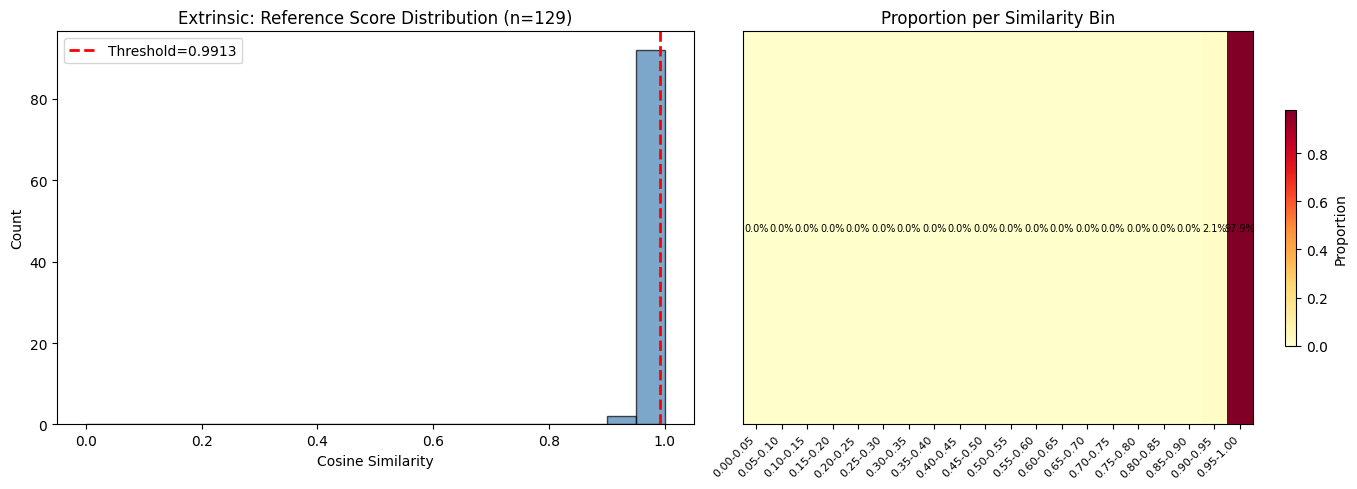

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram of reference scores
bins = np.arange(0.0, 1.05, 0.05)
counts, _, patches = axes[0].hist(scores_extrinsic, bins=bins, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(ci_low_e, color='red', linestyle='--', linewidth=2, label=f'Threshold={ci_low_e:.4f}')
axes[0].set_xlabel('Cosine Similarity')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Extrinsic: Reference Score Distribution (n={len(scores_extrinsic)})')
axes[0].legend()

# Right: heatmap of proportion per bin
bin_labels = [f'{b:.2f}-{b+0.05:.2f}' for b in bins[:-1]]
proportions = counts / counts.sum()
heatmap_data = proportions.reshape(1, -1)
im = axes[1].imshow(heatmap_data, aspect='auto', cmap='YlOrRd', vmin=0)
axes[1].set_xticks(range(len(bin_labels)))
axes[1].set_xticklabels(bin_labels, rotation=45, ha='right', fontsize=8)
axes[1].set_yticks([])
axes[1].set_title('Proportion per Similarity Bin')
for j in range(len(bin_labels)):
    axes[1].text(j, 0, f'{proportions[j]:.1%}', ha='center', va='center', fontsize=7)
fig.colorbar(im, ax=axes[1], shrink=0.6, label='Proportion')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR_EXT, 'extrinsic_threshold_distribution.png'), dpi=150)
plt.show()

##### 3.2.2.1b Embedding Model B (bge-base): Reference PDDL vs Generated PDDL Similarity

Repeat the extrinsic embedding evaluation using `BAAI/bge-base-en-v1.5`.

In [ ]:
# --- Extrinsic embedding with model B (bge-base) ---
emb_extrinsic_results_b = []
eval_set_path = Path(EVAL_SET_DIR)
for cve_dir in sorted(eval_set_path.iterdir()):
    if not cve_dir.is_dir():
        continue
    cve_id = cve_dir.name
    ref_aps = ref_by_cve.get(cve_id, [])
    if not ref_aps:
        print(f"SKIP {cve_id}: no reference APs in dataset")
        continue

    gen_texts = []
    gen_labels = []
    for config_dir in sorted(cve_dir.iterdir()):
        if not config_dir.is_dir():
            continue
        domain_file = config_dir / DOMAIN_FILE
        problem_file = config_dir / PROBLEM_FILE
        if not domain_file.exists():
            continue
        domain = domain_file.read_text(encoding='utf-8').strip()
        problem = problem_file.read_text(encoding='utf-8').strip() if problem_file.exists() else ''
        gen_texts.append(domain + '\n' + problem)
        gen_labels.append(config_dir.name)

    if not gen_texts:
        continue

    ref_texts = [ap['domain'] + '\n' + ap['problem'] for ap in ref_aps]
    ref_labels = [ap['ap_id'] for ap in ref_aps]

    sim_matrix_b = embedding_similarity_extrinsic(gen_texts, ref_texts, embedding_model_b)

    for i, gen_label in enumerate(gen_labels):
        for j, ref_label in enumerate(ref_labels):
            sim = float(sim_matrix_b[i, j])
            emb_extrinsic_results_b.append({
                'cve_id': cve_id,
                'generated': gen_label,
                'reference': ref_label,
                'similarity': sim,
            })
            print(f"[Model B] {cve_id}/{gen_label} vs {ref_label}  similarity: {sim:.4f}")

[Model B] CVE-2022-1471/gpt41_baseline_cveonly vs AP1  similarity: 0.9772
[Model B] CVE-2022-1471/gpt41mini_ctx_feedback vs AP1  similarity: 0.9430
[Model B] CVE-2022-1471/gpt4mini_1shot_augmented vs AP1  similarity: 0.9048
[Model B] CVE-2022-1471/reference vs AP1  similarity: 1.0000
[Model B] CVE-2023-44487/gpt41mini_ctx_feedback vs AP1  similarity: 0.9718
[Model B] CVE-2023-44487/gpt41mini_feedback vs AP1  similarity: 0.9667
[Model B] CVE-2023-6378/reference vs AP1  similarity: 1.0000
[Model B] CVE-2025-24813/gpt41_ctx_feedback_v2 vs AP1  similarity: 0.9777
[Model B] CVE-2025-24813/gpt41_ctx_feedback_v2 vs AP2  similarity: 0.9756
[Model B] CVE-2025-24813/gpt41_ctx_feedback_v2 vs AP3  similarity: 0.9755
[Model B] CVE-2025-24813/reference vs AP1  similarity: 0.9944
[Model B] CVE-2025-24813/reference vs AP2  similarity: 0.9946
[Model B] CVE-2025-24813/reference vs AP3  similarity: 1.0000
SKIP CVE-2025-66032: no reference APs in dataset


In [ ]:
# --- Extrinsic threshold for model B ---
scores_extrinsic_b = collect_reference_scores_extrinsic(dataset, embedding_model_b)
ci_low_eb, ci_high_eb, boot_means_eb = bootstrap_threshold(scores_extrinsic_b, seed=SEED)

print(f"Extrinsic threshold (model={EMBEDDING_MODEL_NAME_B}, n={len(scores_extrinsic_b)})")
print(f"  mean={scores_extrinsic_b.mean():.4f}  std={scores_extrinsic_b.std():.4f}  "
      f"min={scores_extrinsic_b.min():.4f}  max={scores_extrinsic_b.max():.4f}")
print(f"  95% CI of mean: [{ci_low_eb:.4f}, {ci_high_eb:.4f}]")
print(f"  Suggested threshold (CI lower bound): {ci_low_eb:.4f}")

# --- Compare model A vs model B ---
print(f"\n--- Extrinsic Comparison ---")
print(f"  Model A ({EMBEDDING_MODEL_NAME}):  mean={scores_extrinsic.mean():.4f}  threshold={ci_low_e:.4f}")
print(f"  Model B ({EMBEDDING_MODEL_NAME_B}):  mean={scores_extrinsic_b.mean():.4f}  threshold={ci_low_eb:.4f}")

Extrinsic threshold (model=BAAI/bge-base-en-v1.5, n=129)
  mean=0.9976  std=0.0029  min=0.9894  max=1.0000
  95% CI of mean: [0.9971, 0.9981]
  Suggested threshold (CI lower bound): 0.9971

--- Extrinsic Comparison ---
  Model A (all-MiniLM-L6-v2):  mean=0.9930  threshold=0.9913
  Model B (BAAI/bge-base-en-v1.5):  mean=0.9976  threshold=0.9971


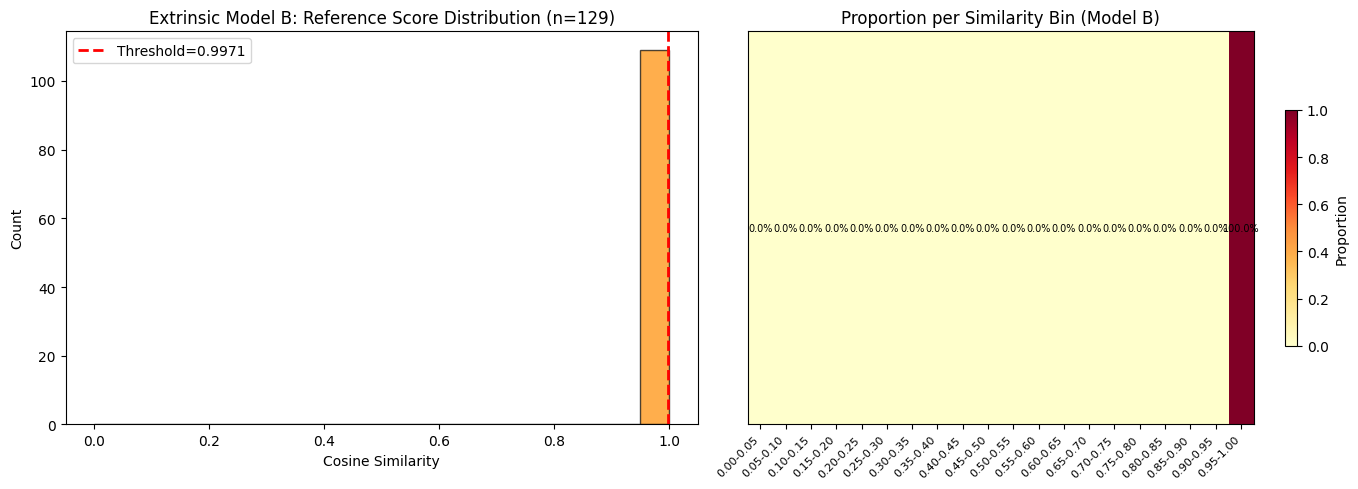

In [ ]:
# --- Visualize extrinsic distribution for model B ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins = np.arange(0.0, 1.05, 0.05)
counts, _, patches = axes[0].hist(scores_extrinsic_b, bins=bins, edgecolor='black', alpha=0.7, color='darkorange')
axes[0].axvline(ci_low_eb, color='red', linestyle='--', linewidth=2, label=f'Threshold={ci_low_eb:.4f}')
axes[0].set_xlabel('Cosine Similarity')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Extrinsic Model B: Reference Score Distribution (n={len(scores_extrinsic_b)})')
axes[0].legend()

bin_labels = [f'{b:.2f}-{b+0.05:.2f}' for b in bins[:-1]]
proportions = counts / counts.sum()
heatmap_data = proportions.reshape(1, -1)
im = axes[1].imshow(heatmap_data, aspect='auto', cmap='YlOrRd', vmin=0)
axes[1].set_xticks(range(len(bin_labels)))
axes[1].set_xticklabels(bin_labels, rotation=45, ha='right', fontsize=8)
axes[1].set_yticks([])
axes[1].set_title('Proportion per Similarity Bin (Model B)')
for j in range(len(bin_labels)):
    axes[1].text(j, 0, f'{proportions[j]:.1%}', ha='center', va='center', fontsize=7)
fig.colorbar(im, ax=axes[1], shrink=0.6, label='Proportion')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR_EXT, 'extrinsic_threshold_distribution_model_b.png'), dpi=150)
plt.show()

##### k4block/CodeBLEU

- Couldn't be integrated without effort, skip.
  - reason: 
    - CodeBLEU requires a **tree-sitter grammar** for the target language. 
    - CodeBLEU only supports 10 languages (Java, Python, C, etc.), with **no custom grammar interface**. 
    - No exisiting PDDL `tree-sitter` grammar, no [`tree-sitter-pddl`](https://github.com/tree-sitter/tree-sitter/wiki/List-of-parsers?utm_source=chatgpt.com)
- Other implementations: [Microsoft CodeXGLUE](https://github.com/microsoft/codexglue?utm_source=chatgpt.com), [Microsoft CodeBERT/CodeReviewer](https://github.com/microsoft/CodeBERT/blob/master/CodeReviewer/code/evaluator/CodeBLEU/calc_code_bleu.py?utm_source=chatgpt.com), also **No**.

##### 3.2.2.2 LLM as an Expert — Reference PDDL vs Candidate PDDL Match

##### 3.2.2.2a TRUE/FALSE
`llm_eval_extrinsic_binary`: generic classification using `llm_extrinsic_binary.jinja`

Block 1: the function to prompt an LLM with a binary True/False evaluation

In [ ]:
extrinsic_binary_template = prompt_env.get_template("llm_extrinsic_binary.jinja")

def llm_eval_extrinsic_binary(cve_id, description, domain_reference, problem_reference,
                              domain_generated, problem_generated, client, model, seed=42):
    """Binary True/False: does the candidate match the reference?"""
    prompt = extrinsic_binary_template.render(
        cve_id=cve_id, description=description,
        domain_reference=domain_reference, problem_reference=problem_reference,
        domain_generated=domain_generated, problem_generated=problem_generated,
    )
    resp = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        temperature=0.0,
        max_tokens=512,
        seed=seed,
    )
    return resp.choices[0].message.content


Block 2: call the function with the code and the specifications from the data set

In [ ]:
llm_extrinsic_binary_results = []
eval_set_path = Path(EVAL_SET_DIR)
for cve_dir in sorted(eval_set_path.iterdir()):
    if not cve_dir.is_dir():
        continue
    cve_id = cve_dir.name
    description = cve_descriptions.get(cve_id)
    ref_aps = ref_by_cve.get(cve_id, [])
    if description is None or not ref_aps:
        print(f"SKIP {cve_id}: no description or no reference APs")
        continue
    for config_dir in sorted(cve_dir.iterdir()):
        if not config_dir.is_dir():
            continue
        domain_file = config_dir / DOMAIN_FILE
        problem_file = config_dir / PROBLEM_FILE
        if not domain_file.exists():
            continue
        domain_generated = domain_file.read_text(encoding="utf-8").strip()
        problem_generated = problem_file.read_text(encoding="utf-8").strip() if problem_file.exists() else ""
        for ref_ap in ref_aps:
            response = llm_eval_extrinsic_binary(
                cve_id, description, ref_ap["domain"], ref_ap["problem"],
                domain_generated, problem_generated, nvidia, NVIDIA_MODEL, seed=SEED
            )
            result = {
                "cve_id": cve_id, "generated": config_dir.name,
                "reference": ref_ap["ap_id"], "llm_response": response,
            }
            llm_extrinsic_binary_results.append(result)
            save_name = f"llm_extrinsic_binary_vs_{ref_ap['ap_id']}.json"
            (config_dir / save_name).write_text(json.dumps(result, indent=2), encoding="utf-8")
            try:
                text = response.strip()
                if text.startswith("```"): text = text.split("\n", 1)[1].rsplit("```", 1)[0]
                label = json.loads(text).get("label", "?")
            except Exception:
                label = "?"
            print(f"{cve_id}/{config_dir.name:30s} vs {ref_ap['ap_id']} | {label}")


CVE-2022-1471/gpt41_baseline_cveonly         vs AP1 | False
CVE-2022-1471/gpt41mini_ctx_feedback         vs AP1 | True
CVE-2022-1471/gpt4mini_1shot_augmented       vs AP1 | False
CVE-2022-1471/reference                      vs AP1 | False
CVE-2023-44487/gpt41mini_ctx_feedback         vs AP1 | False
CVE-2023-44487/gpt41mini_feedback             vs AP1 | False
CVE-2023-6378/reference                      vs AP1 | True
CVE-2025-24813/gpt41_ctx_feedback_v2          vs AP1 | False
CVE-2025-24813/gpt41_ctx_feedback_v2          vs AP2 | False
CVE-2025-24813/gpt41_ctx_feedback_v2          vs AP3 | False
CVE-2025-24813/reference                      vs AP1 | False
CVE-2025-24813/reference                      vs AP2 | False
CVE-2025-24813/reference                      vs AP3 | False
SKIP CVE-2025-66032: no description or no reference APs


##### 3.2.2.2b Sophisticated Extrinsic Evaluation
`llm_eval_extrinsic_scored`: sophisticated evaluation using `llm_extrinsic.jinja` (13-criteria Likert 1-5)

Block 1: the function to prompt an LLM with the 13-criteria scoring rubric

In [ ]:
extrinsic_scored_template = prompt_env.get_template("llm_extrinsic.jinja")

def llm_eval_extrinsic_scored(cve_id, description, domain_reference, problem_reference,
                             domain_generated, problem_generated, client, model, seed=42):
    """Sophisticated 13-criteria Likert 1-5 evaluation (10 semantic + 3 reference-comparison)."""
    prompt = extrinsic_scored_template.render(
        cve_id=cve_id, description=description,
        domain_reference=domain_reference, problem_reference=problem_reference,
        domain_generated=domain_generated, problem_generated=problem_generated,
    )
    resp = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        temperature=0.0,
        max_tokens=4096,
        seed=seed,
    )
    return resp.choices[0].message.content


Block 2: call the function with the code and the specifications from the data set

In [ ]:
llm_extrinsic_scored_results = []
eval_set_path = Path(EVAL_SET_DIR)
print("Domain".ljust(45) + " | Ref  | #A | F1 | F2 | A1 | A2 | C1 | C2 | C3 | V1 | V2 | V3 | R1 | R2 | R3 | R4 | Avg")
print("-" * 150)
for cve_dir in sorted(eval_set_path.iterdir()):
    if not cve_dir.is_dir():
        continue
    cve_id = cve_dir.name
    description = cve_descriptions.get(cve_id)
    ref_aps = ref_by_cve.get(cve_id, [])
    if description is None or not ref_aps:
        print(f"SKIP {cve_id}: no description or no reference APs")
        continue
    for config_dir in sorted(cve_dir.iterdir()):
        if not config_dir.is_dir():
            continue
        domain_file = config_dir / DOMAIN_FILE
        problem_file = config_dir / PROBLEM_FILE
        if not domain_file.exists():
            continue
        domain_generated = domain_file.read_text(encoding="utf-8").strip()
        problem_generated = problem_file.read_text(encoding="utf-8").strip() if problem_file.exists() else ""
        for ref_ap in ref_aps:
            response = llm_eval_extrinsic_scored(
                cve_id, description, ref_ap["domain"], ref_ap["problem"],
                domain_generated, problem_generated, nvidia, NVIDIA_MODEL, seed=SEED
            )
            result = {
                "cve_id": cve_id, "generated": config_dir.name,
                "reference": ref_ap["ap_id"], "llm_response": response,
            }
            llm_extrinsic_scored_results.append(result)
            save_name = f"llm_extrinsic_scored_vs_{ref_ap['ap_id']}.json"
            (config_dir / save_name).write_text(json.dumps(result, indent=2), encoding="utf-8")
            print(summarize_extrinsic_scored(result))


Domain                                        | Ref  | #A | F1 | F2 | A1 | A2 | C1 | C2 | C3 | V1 | V2 | V3 | R1 | R2 | R3 | R4 | Avg
------------------------------------------------------------------------------------------------------------------------------------------------------
CVE-2022-1471/gpt41_baseline_cveonly         vs AP1 |  8 |  5.0 |  5.0 |  5.0 |  5.0 | 5 | 5 | 5 | 5 | 5 | 5 | 5 | 5 | 5 | 5 | 5.00
CVE-2022-1471/gpt41mini_ctx_feedback         vs AP1 |  8 |  5.0 |  5.0 |  5.0 |  5.0 | 5 | 5 | 5 | 5 | 5 | 5 | 5 | 5 | 5 | 5 | 5.00
CVE-2022-1471/gpt4mini_1shot_augmented       vs AP1 |  6 |  4.5 |  4.8 |  4.7 |  4.8 | 4 | 4 | 5 | 3 | 4 | 5 | 4 | 4 | 4 | 3 | 4.20
CVE-2022-1471/reference vs AP1  PARSE_ERROR
CVE-2023-44487/gpt41mini_ctx_feedback         vs AP1 |  9 |  5.0 |  5.0 |  5.0 |  5.0 | 5 | 5 | 5 | 5 | 5 | 5 | 5 | 5 | 5 | 5 | 5.00


APITimeoutError: Request timed out.

Block 3: call the function with GPT-4.1-mini (reuses `parse_scored_response` and `summarize_extrinsic_scored` from intrinsic section)

In [ ]:
# from dotenv import load_dotenv
# load_dotenv(override=True)

# openai_client = OpenAI(
#     api_key=os.getenv("OPENAI_API_KEY"),
#     timeout=120.0,
# )

# llm_extrinsic_scored_results_gpt = []
# eval_set_path = Path(EVAL_SET_DIR)
# print("Domain".ljust(45) + " | Ref  | #A | F1 | F2 | A1 | A2 | C1 | C2 | C3 | V1 | V2 | V3 | R1 | R2 | R3 | R4 | Avg")
# print("-" * 150)
# for cve_dir in sorted(eval_set_path.iterdir()):
#     if not cve_dir.is_dir():
#         continue
#     cve_id = cve_dir.name
#     description = cve_descriptions.get(cve_id)
#     ref_aps = ref_by_cve.get(cve_id, [])
#     if description is None or not ref_aps:
#         print(f"SKIP {cve_id}: no description or no reference APs")
#         continue
#     for config_dir in sorted(cve_dir.iterdir()):
#         if not config_dir.is_dir():
#             continue
#         domain_file = config_dir / DOMAIN_FILE
#         problem_file = config_dir / PROBLEM_FILE
#         if not domain_file.exists():
#             continue
#         domain_generated = domain_file.read_text(encoding="utf-8").strip()
#         problem_generated = problem_file.read_text(encoding="utf-8").strip() if problem_file.exists() else ""
#         for ref_ap in ref_aps:
#             response = llm_eval_extrinsic_scored(
#                 cve_id, description, ref_ap["domain"], ref_ap["problem"],
#                 domain_generated, problem_generated, openai_client, GPT_MODEL, seed=SEED
#             )
#             result = {
#                 "cve_id": cve_id, "generated": config_dir.name,
#                 "reference": ref_ap["ap_id"], "llm_response": response,
#             }
#             llm_extrinsic_scored_results_gpt.append(result)
#             save_name = f"llm_extrinsic_scored_gpt_vs_{ref_ap['ap_id']}.json"
#             (config_dir / save_name).write_text(json.dumps(result, indent=2), encoding="utf-8")
#             print(summarize_extrinsic_scored(result))


Domain                                        | Ref  | #A | F1 | F2 | A1 | A2 | C1 | C2 | C3 | V1 | V2 | V3 | R1 | R2 | R3 | R4 | Avg
------------------------------------------------------------------------------------------------------------------------------------------------------
CVE-2022-1471/gpt41_baseline_cveonly         vs AP1 |  8 |  5.0 |  4.9 |  4.9 |  5.0 | 5 | 4 | 5 | 4 | 4 | 5 | 4 | 3 | 4 | 4 | 4.41
CVE-2022-1471/gpt41mini_ctx_feedback         vs AP1 |  8 |  5.0 |  4.5 |  4.6 |  5.0 | 5 | 3 | 5 | 3 | 3 | 5 | 3 | 3 | 3 | 3 | 3.94
CVE-2022-1471/gpt4mini_1shot_augmented       vs AP1 |  6 |  4.5 |  4.5 |  5.0 |  4.5 | 3 | 2 | 4 | 2 | 2 | 4 | 2 | 2 | 2 | 2 | 3.11
CVE-2022-1471/reference                      vs AP1 | 14 |  5.0 |  5.0 |  5.0 |  5.0 | 5 | 5 | 5 | 5 | 5 | 5 | 5 | 5 | 5 | 5 | 5.00
CVE-2023-6378/reference                      vs AP1 |  8 |  5.0 |  5.0 |  5.0 |  5.0 | 5 | 5 | 5 | 5 | 5 | 5 | 5 | 5 | 5 | 5 | 5.00
SKIP CVE-2025-66032: no description or no reference APs

## 4. Summary: All Evaluation Results by Domain

In [147]:
# Collect all evaluation results per domain
from collections import defaultdict

summary = defaultdict(dict)

# 3.1 Solvability (FF + ENHSP)
eval_set_path = Path(EVAL_SET_DIR)
for cve_dir in sorted(eval_set_path.iterdir()):
    if not cve_dir.is_dir():
        continue
    for config_dir in sorted(cve_dir.iterdir()):
        if not config_dir.is_dir():
            continue
        label = f"{cve_dir.name}/{config_dir.name}"
        planner_file = config_dir / "planner_output.txt"
        if planner_file.exists():
            po = planner_file.read_text()
            summary[label]["solvable"] = "PASS" if "VERDICT: PASS" in po else "FAIL"

# 3.2.1.1 Embedding intrinsic (multiple variants) - store raw similarity
variant_config = {
    "emb_intrinsic_results":   ("emb_a", "ci_low_i"),
    "emb_intrinsic_results_b": ("emb_b", "ci_low_ib"),
    "emb_intrinsic_results_c": ("emb_c", "ci_low_ic"),
    "emb_intrinsic_results_d": ("emb_d", "ci_low_id"),
    "emb_intrinsic_results_e": ("emb_e", "ci_low_ie"),
    "emb_intrinsic_results_f": ("emb_f", "ci_low_if"),
    "emb_intrinsic_results_g": ("emb_g", "ci_low_ig"),
    "emb_intrinsic_results_j": ("emb_j", "ci_low_ij"),
    "emb_intrinsic_results_h": ("emb_h", "ci_low_ih"),
}

# Collect thresholds
thresholds = {}
for var_name, (col_name, thr_name) in variant_config.items():
    thr = globals().get(thr_name)
    if thr is not None:
        thresholds[col_name] = float(thr)
    results = globals().get(var_name, [])
    for r in results:
        sim = r["similarity"]
        thr_val = thresholds.get(col_name)
        if thr_val is not None:
            status = "PASS" if sim >= thr_val else "BELOW"
            summary[r["label"]][col_name] = f"{sim:.3f} {status}"
        else:
            summary[r["label"]][col_name] = f"{sim:.3f}"

# 3.2.1.2a LLM intrinsic binary
for r in globals().get("llm_intrinsic_binary_results", []):
    label = f"{r['cve_id']}/{r['config']}"
    try:
        text = r["llm_response"].strip()
        if text.startswith("```"): text = text.split("\n", 1)[1].rsplit("```", 1)[0]
        lbl = json.loads(text).get("label", "?")
    except Exception:
        lbl = "?"
    summary[label]["llm_binary"] = lbl

# 3.2.1.2b LLM intrinsic scored (nvidia)
for r in globals().get("llm_intrinsic_scored_results", []):
    label = f"{r['cve_id']}/{r['config']}"
    data = parse_scored_response(r["llm_response"])
    if data:
        actions = data.get("actions", [])
        scores = []
        for key in ["F1","F2","A1","A2"]:
            vals = [a[key] for a in actions if key in a]
            if vals: scores.append(sum(vals)/len(vals))
        for key in ["C1","C2","C3","V1","V2","V3"]:
            if key in data: scores.append(data[key])
        avg = sum(scores)/len(scores) if scores else 0
        summary[label]["llm_scored_nvidia"] = f"{avg:.2f}"
    else:
        summary[label]["llm_scored_nvidia"] = "ERR"

# 3.2.1.2b LLM intrinsic scored (GPT)
for r in globals().get("llm_intrinsic_scored_results_gpt", []):
    label = f"{r['cve_id']}/{r['config']}"
    data = parse_scored_response(r["llm_response"])
    if data:
        actions = data.get("actions", [])
        scores = []
        for key in ["F1","F2","A1","A2"]:
            vals = [a[key] for a in actions if key in a]
            if vals: scores.append(sum(vals)/len(vals))
        for key in ["C1","C2","C3","V1","V2","V3"]:
            if key in data: scores.append(data[key])
        avg = sum(scores)/len(scores) if scores else 0
        summary[label]["llm_scored_gpt"] = f"{avg:.2f}"
    else:
        summary[label]["llm_scored_gpt"] = "ERR"

# 3.2.2.1 Embedding extrinsic (Model A + Model B)
ext_emb_config = {
    "emb_extrinsic_results":   ("ext_a", "ci_low_e"),
    "emb_extrinsic_results_b": ("ext_b", "ci_low_eb"),
}
for var_name, (prefix, thr_name) in ext_emb_config.items():
    thr = globals().get(thr_name)
    if thr is not None:
        thresholds[prefix] = float(thr)
    for r in globals().get(var_name, []):
        label = f"{r['cve_id']}/{r['generated']}"
        col = f"{prefix}_{r['reference']}"
        sim = r["similarity"]
        thr_val = thresholds.get(prefix)
        if thr_val is not None:
            status = "PASS" if sim >= thr_val else "BELOW"
            summary[label][col] = f"{sim:.3f} {status}"
        else:
            summary[label][col] = f"{sim:.3f}"

# 3.2.2.2a LLM extrinsic binary
for r in globals().get("llm_extrinsic_binary_results", []):
    label = f"{r['cve_id']}/{r['generated']}"
    try:
        text = r["llm_response"].strip()
        if text.startswith("```"): text = text.split("\n", 1)[1].rsplit("```", 1)[0]
        lbl = json.loads(text).get("label", "?")
    except Exception:
        lbl = "?"
    summary[label][f"ext_binary_{r['reference']}"] = lbl

# 3.2.2.2b LLM extrinsic scored (nvidia)
for r in globals().get("llm_extrinsic_scored_results", []):
    label = f"{r['cve_id']}/{r['generated']}"
    data = parse_scored_response(r["llm_response"])
    if data:
        actions = data.get("actions", [])
        scores = []
        for key in ["F1","F2","A1","A2"]:
            vals = [a[key] for a in actions if key in a]
            if vals: scores.append(sum(vals)/len(vals))
        for key in ["C1","C2","C3","V1","V2","V3","R1","R2","R3","R4"]:
            if key in data: scores.append(data[key])
        avg = sum(scores)/len(scores) if scores else 0
        summary[label][f"ext_scored_nv_{r['reference']}"] = f"{avg:.2f}"
    else:
        summary[label][f"ext_scored_nv_{r['reference']}"] = "ERR"

# 3.2.2.2b LLM extrinsic scored (GPT)
for r in globals().get("llm_extrinsic_scored_results_gpt", []):
    label = f"{r['cve_id']}/{r['generated']}"
    data = parse_scored_response(r["llm_response"])
    if data:
        actions = data.get("actions", [])
        scores = []
        for key in ["F1","F2","A1","A2"]:
            vals = [a[key] for a in actions if key in a]
            if vals: scores.append(sum(vals)/len(vals))
        for key in ["C1","C2","C3","V1","V2","V3","R1","R2","R3","R4"]:
            if key in data: scores.append(data[key])
        avg = sum(scores)/len(scores) if scores else 0
        summary[label][f"ext_scored_gpt_{r['reference']}"] = f"{avg:.2f}"
    else:
        summary[label][f"ext_scored_gpt_{r['reference']}"] = "ERR"

# Collect all columns dynamically
all_cols_set = set()
for label in summary:
    all_cols_set.update(summary[label].keys())

# Order: solvable, intrinsic embedding, intrinsic LLM, extrinsic embedding, extrinsic LLM
intrinsic_emb = sorted(c for c in all_cols_set if c.startswith("emb_"))
intrinsic_llm = ["llm_binary", "llm_scored_nvidia", "llm_scored_gpt"]
extrinsic_cols = sorted(c for c in all_cols_set if c.startswith("ext_"))
all_cols = (["solvable"] + intrinsic_emb +
            [c for c in intrinsic_llm if c in all_cols_set] +
            extrinsic_cols)
seen = set()
all_cols = [c for c in all_cols if not (c in seen or seen.add(c))]

# Print summary table
header = "Domain".ljust(45) + " | " + " | ".join(c.rjust(16) for c in all_cols)
print(header)
print("-" * len(header))
for label in sorted(summary.keys()):
    row = label.ljust(45) + " | "
    row += " | ".join(str(summary[label].get(c, "-")).rjust(16) for c in all_cols)
    print(row)

# Threshold row
thr_row = "THRESHOLD".ljust(45) + " | "
for c in all_cols:
    # Find matching threshold
    thr_val = thresholds.get(c)
    if thr_val is not None:
        thr_row += f"{thr_val:.4f}".rjust(16) + " | "
    else:
        thr_row += "-".rjust(16) + " | "
print("-" * len(header))
print(thr_row)

# Save summary to JSON
summary_json = {label: dict(vals) for label, vals in summary.items()}
summary_json["_thresholds"] = thresholds
eval_set_path = Path(EVAL_SET_DIR)
(eval_set_path / "evaluation_summary.json").write_text(json.dumps(summary_json, indent=2), encoding="utf-8")
print(f"\nSummary saved to {eval_set_path / 'evaluation_summary.json'}")


Domain                                        |         solvable |            emb_a |            emb_b |            emb_c |            emb_d |            emb_e |            emb_f |            emb_g |            emb_h |            emb_j |       llm_binary | llm_scored_nvidia |   llm_scored_gpt |        ext_a_AP1 |        ext_a_AP2 |        ext_a_AP3 |        ext_b_AP1 |        ext_b_AP2 |        ext_b_AP3 |   ext_binary_AP1 |   ext_binary_AP2 |   ext_binary_AP3 | ext_scored_nv_AP1
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
CVE-2022-1471/gpt41_baseline_c

##### Analysis
- Intrisinc
  - embedding similarity
    - Expectations
       - the similarity of CVE-2025-24813/reference, CVE-2022-1471/reference > threshold
       - CVE-2022-1471/gpt4mini_1shot_augmented, CVE-2025-66032/gpt4_1shot, CVE-2025-66032/qwen-max_1shot < threshold
    - emb_e, emb_f, emb_g, emg_h, emb_j meet the expectations
      - but emb_f, emb_g, emg_h, emb_j (accumulative per-action similarity) too strict, only reference pass.
         - but still have the space to refine.
      - **emb_e**: TI-selected NL (description + CAPEC + CVSS vector) vs action names meets both the expectation and not that too strict
  -  llm-as-expert
    - llm_scored_gpt can distinguish bad and good to some extent